# BTR-Transformer

**73.69 Large Language Models (2026) — Trabajo Práctico 1**

Impression-level binary classification of `bought` as a product-level contribution to supermarket e-commerce **Buy Through Rate** (purchases / impressions). No decision threshold. Ranking quality of bought=1 is measured with ROC-AUC and PR-AUC.

Architecture: a **small Transformer encoder trained from scratch** on product text (`title`, `description`, `ingredients`), concatenated with a tabular vector, then an MLP → 1 logit. BERT is used **only as a tokenizer**; encoder weights are random `nn.Embedding`, not a pretrained LLM backbone.

This notebook covers setup through the training machinery (cell groups 0–7). Baselines, the three ablation arms, scale-up, and Exercise 3 are placeholders at the end.

## Locked constraints

- **`cart` is leakage**, not a feature. \(P(bought \mid cart=	ext{false}) = 0\); using it would change the task from BTR among impressions to conversion among cart-adds. See [`adr/0002`](../adr/0002-leakage-cart-query-id.md).
- **`query_id` is a split grouping key**, never a model input. Impressions from the same search must not leak across train/valid/test. See [`adr/0005`](../adr/0005-grouped-splits.md).
- The catalog text **encodes the target** via a behavioural cue in `title` (and restated in `description`). Arm A vs C measures cue visibility; **B vs C** is the only pair that speaks to self-attention on product language. See [`adr/0009`](../adr/0009-text-behavioural-cue.md).

Design: [`docs/DESIGN.md`](../docs/DESIGN.md) · data facts: [`docs/EDA.md`](../docs/EDA.md) · decisions: [`docs/OPEN_DECISIONS.md`](../docs/OPEN_DECISIONS.md) · ADRs: [`adr/`](../adr/).


## 1. Environment and data loading

Setup is a **shell** step, not a notebook cell (D21):

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
```

GPU is used if present; this dataset trains on CPU in minutes ([`DESIGN.md`](../docs/DESIGN.md) §8). The next cell asserts the pinned versions from `requirements.txt` and fails loudly on mismatch rather than installing.


In [1]:
from __future__ import annotations

from importlib.metadata import version as _pkg_version

EXPECTED = {
    "torch": "2.13.0",
    "pandas": "2.3.3",
    "scikit-learn": "1.7.2",
    "transformers": "5.16.1",
}


def _base_version(v: str) -> str:
    return v.split("+")[0]


for dist, want in EXPECTED.items():
    got = _base_version(_pkg_version(dist))
    assert got == want, f"{dist}: expected {want}, got {got}"

print("version assertions OK:", {k: _base_version(_pkg_version(k)) for k in EXPECTED})


version assertions OK: {'torch': '2.13.0', 'pandas': '2.3.3', 'scikit-learn': '1.7.2', 'transformers': '5.16.1'}


In [2]:
import inspect
import json
import math
import os
import random
import re
import time
from collections.abc import Sequence
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from huggingface_hub import constants as hf_constants
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer

# --- Hyperparameters ---
SEED = 42
BATCH_SIZE = 64
MAX_LENGTH = 80
MAX_EPOCHS = 30
PATIENCE = 5
LR = 3e-4
WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0
ARM_SEEDS: tuple[int, ...] = (42, 43, 44, 45, 46)

# BTR_FAST=1 shrinks the experiment grid to a smoke-test budget so the notebook
# can be validated end-to-end in ~2 minutes. It changes no design decision.
FAST = os.environ.get("BTR_FAST") == "1"
if FAST:
    ARM_SEEDS = (42,)
    MAX_EPOCHS = 2
    PATIENCE = 1
    print("BTR_FAST=1 -> smoke budget: 1 seed, 2 epochs. Results are NOT reportable.")

GRID_SEEDS: tuple[int, ...] = ARM_SEEDS


# --- Reproducibility ---
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(SEED)

# --- Device ---
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device={device}")
print(f"HF_HOME={hf_constants.HF_HOME}")
print(f"HF_HUB_CACHE={hf_constants.HF_HUB_CACHE}")

# --- Tokenizer (WordPiece vocab only; encoder weights stay random) ---
try:
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)
except OSError:
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print(f"tokenizer={tokenizer.name_or_path} vocab_size={tokenizer.vocab_size} sep={tokenizer.sep_token!r}")


device=cpu
HF_HOME=C:\Users\Admin\.cache\huggingface
HF_HUB_CACHE=C:\Users\Admin\.cache\huggingface\hub
tokenizer=bert-base-uncased vocab_size=30522 sep='[SEP]'


### CSV schema 

Default path: `data/raw/supermarket_products.csv`. Override with env `BTR_DATA_PATH` (absolute or repo-relative).

Required columns (names + roles). Row count, missingness rates, and class balance are **data-dependent** — printed, not asserted to fixed values.

| Role | Columns |
| --- | --- |
| Target | `bought` |
| Leakage drop | `cart` |
| Split key | `query_id` |
| Text | `title`, `description`, `ingredients` |
| Numeric / parse | `price`, `net_weight_oz`, `nutrition_score`, `dimensions_in`, `package_size` |
| Categorical | `category`, `brand`, `storage_type`, `unit_of_measure`, `country_of_origin`, `allergens` |
| Filters | `filter_category`, `filter_storage_type`, `filter_price_min`, `filter_price_max` |
| Time | `timestamp` |

Structural checks on load: required columns present; `bought` / `cart` boolean-like; every purchase implies `cart=True` (else `cart` is not pure leakage); ≥2 queries and both purchase regimes for stratified grouped split.


In [3]:
REQUIRED_COLUMNS: frozenset[str] = frozenset(
    {
        "bought",
        "cart",
        "query_id",
        "title",
        "description",
        "ingredients",
        "price",
        "net_weight_oz",
        "nutrition_score",
        "dimensions_in",
        "package_size",
        "category",
        "brand",
        "storage_type",
        "unit_of_measure",
        "country_of_origin",
        "allergens",
        "filter_category",
        "filter_storage_type",
        "filter_price_min",
        "filter_price_max",
        "timestamp",
    }
)
DEFAULT_CSV_REL = Path("data") / "raw" / "supermarket_products.csv"


def resolve_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "requirements.txt").exists() and (cand / "data" / "raw").is_dir():
            return cand
        if (cand / DEFAULT_CSV_REL).exists():
            return cand
    raise FileNotFoundError(
        "Could not find repo root (requirements.txt + data/raw/) from cwd or parents."
    )


def resolve_data_path() -> Path:
    override = os.environ.get("BTR_DATA_PATH")
    if override:
        p = Path(override).expanduser()
        return p if p.is_absolute() else (Path.cwd() / p).resolve()
    return resolve_repo_root() / DEFAULT_CSV_REL


def validate_raw_frame(frame: pd.DataFrame) -> None:
    missing = REQUIRED_COLUMNS - set(frame.columns)
    assert not missing, f"missing required columns: {sorted(missing)}"
    extra = set(frame.columns) - REQUIRED_COLUMNS
    if extra:
        print(f"note: extra columns ignored later: {sorted(extra)}")

    assert len(frame) >= 2, "need at least 2 rows"
    bought = frame["bought"].astype(int)
    cart = frame["cart"].astype(int)
    assert set(bought.unique()) <= {0, 1}, "bought must be binary / boolean-like"
    assert set(cart.unique()) <= {0, 1}, "cart must be binary / boolean-like"
    n_leak = int((~frame["cart"].astype(bool) & frame["bought"].astype(bool)).sum())
    assert n_leak == 0, (
        f"{n_leak} rows have bought=True with cart=False; cart is not pure leakage"
    )

    n_queries = int(frame["query_id"].nunique())
    assert n_queries >= 2, "need ≥2 distinct query_id for a grouped split"
    has_purchase = frame.groupby("query_id")["bought"].max().astype(int)
    assert has_purchase.nunique() == 2, (
        "stratified query split needs both purchase and no-purchase queries"
    )


REPO_ROOT = resolve_repo_root()
DATA_PATH = resolve_data_path()
print(f"REPO_ROOT={REPO_ROOT}")
print(f"DATA_PATH={DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
validate_raw_frame(df_raw)

print("shape", df_raw.shape)
print("dtypes:\n", df_raw.dtypes.to_string())
print("\nmissingness (%):\n", df_raw.isna().mean().mul(100).round(2).to_string())
print(f"\nbought rate: {df_raw['bought'].astype(float).mean():.4f}")
print("cart × bought:")
print(pd.crosstab(df_raw["cart"], df_raw["bought"]))
print(f"n query_id: {df_raw['query_id'].nunique()}")
print(df_raw.groupby("query_id").size().describe().to_string())
print("schema OK (invariants only; no row-count / rate fingerprints)")


REPO_ROOT=C:\Users\Admin\Desktop\REPOS-ITBA\tp1-llm
DATA_PATH=C:\Users\Admin\Desktop\REPOS-ITBA\tp1-llm\data\raw\supermarket_products.csv
shape (10000, 22)
dtypes:
 title                   object
description             object
price                  float64
category                object
timestamp               object
query_id                object
filter_category         object
filter_price_min       float64
filter_price_max       float64
filter_storage_type     object
cart                      bool
bought                    bool
brand                   object
package_size            object
unit_of_measure         object
net_weight_oz          float64
dimensions_in           object
storage_type            object
ingredients             object
allergens               object
nutrition_score          int64
country_of_origin       object

missingness (%):
 title                   0.00
description             0.00
price                   0.00
category                0.00
timestamp         

In [4]:
def split_queries(
    frame: pd.DataFrame,
    seed: int,
    train_frac: float = 0.70,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Grouped 70/15/15 split of query_id, stratified on has-≥1-purchase."""
    labels = frame.groupby("query_id")["bought"].max().astype(int)
    ids = labels.index.to_numpy()
    y = labels.to_numpy()
    train_ids, rest_ids, _, rest_y = train_test_split(
        ids, y, train_size=train_frac, random_state=seed, stratify=y
    )
    valid_ids, test_ids = train_test_split(
        rest_ids, test_size=0.5, random_state=seed, stratify=rest_y
    )
    return train_ids, valid_ids, test_ids


TITLE_CUE_RE = re.compile(r"\(([^()]*)\)\s*$")
cue = df_raw["title"].str.extract(TITLE_CUE_RE)[0].fillna("None")
print(f"titles with no parenthetical: {(cue == 'None').sum()}")
print(f"n distinct cue levels (incl. None): {cue.nunique()}")
print("\ncue × bought (purchase rate, n):")
print(
    pd.crosstab(cue, df_raw["bought"], normalize="index")
    .join(cue.value_counts().rename("n"))
    .sort_values("n", ascending=False)
    .to_string()
)

probe_train_ids, _, probe_test_ids = split_queries(df_raw, seed=SEED)
train_mask = df_raw["query_id"].isin(probe_train_ids)
test_mask = df_raw["query_id"].isin(probe_test_ids)
y_test = df_raw.loc[test_mask, "bought"].astype(int).to_numpy()

# Cue-rate probe: P(bought | cue) from train queries → score test.
train_rate = (
    pd.DataFrame({"cue": cue[train_mask], "bought": df_raw.loc[train_mask, "bought"]})
    .groupby("cue")["bought"]
    .mean()
)
cue_pred = cue[test_mask].map(train_rate).fillna(df_raw.loc[train_mask, "bought"].mean())
print(
    f"\ncue-rate probe  ROC-AUC={roc_auc_score(y_test, cue_pred):.3f}  "
    f"PR-AUC={average_precision_score(y_test, cue_pred):.3f}  "
    f"prevalence={y_test.mean():.3f}"
)

# TF-IDF probe: bag-of-words on catalog text → logistic regression.
text_concat = (
    df_raw["title"].astype(str)
    + " "
    + df_raw["description"].astype(str)
    + " "
    + df_raw["ingredients"].astype(str)
)
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3)
clf = LogisticRegression(max_iter=1_000, solver="liblinear")
clf.fit(tfidf.fit_transform(text_concat[train_mask]), df_raw.loc[train_mask, "bought"].astype(int))
tfidf_pred = clf.predict_proba(tfidf.transform(text_concat[test_mask]))[:, 1]
print(
    f"TF-IDF probe    ROC-AUC={roc_auc_score(y_test, tfidf_pred):.3f}  "
    f"PR-AUC={average_precision_score(y_test, tfidf_pred):.3f}"
)


titles with no parenthetical: 511
n distinct cue levels (incl. None): 20

cue × bought (purchase rate, n):
                       False      True    n
0                                          
Discontinuing Soon  1.000000  0.000000  550
Limited Feedback    1.000000  0.000000  524
New Listing         1.000000  0.000000  522
Highly Rated        0.978846  0.021154  520
Unrated Listing     1.000000  0.000000  517
Current Stock       1.000000  0.000000  515
None                1.000000  0.000000  511
Clearance Listing   1.000000  0.000000  510
Shopper Favorite    0.972387  0.027613  507
Standard Listing    1.000000  0.000000  506
Rarely Reordered    1.000000  0.000000  500
#1 Pick             0.375000  0.625000  496
Regular Listing     1.000000  0.000000  494
Customer Favorite   0.322515  0.677485  493
Recently Added      1.000000  0.000000  481
Well Reviewed       0.962264  0.037736  477
Top Rated           0.372881  0.627119  472
Best Seller         0.342553  0.657447  470
Popular Choic

TF-IDF probe    ROC-AUC=0.963  PR-AUC=0.690


### EDA conclusions

Interpret the **printed** tables above; numbers in [`docs/EDA.md`](../docs/EDA.md) are for the default course CSV only.

- **`cart` leakage:** validated on load — no `bought=True` when `cart=False`. Drop `cart`.
- **Imbalance:** use the printed `bought` rate. Primary metric is PR-AUC; ROC-AUC alongside. No threshold.
- **Filter flags:** compute match flags, log variance, **drop zero-variance columns** (D1). Keep `relative_price_position` only from the filter block.
- **Behavioural cue:** title parentheticals (and mirrored description sentences) can encode purchase propensity. Cue-rate / TF-IDF probes measure text signal before any Transformer claim. Arm A's headline is cue visibility; **B vs C** is the architecture comparison.


## 2. Feature engineering

Dropped before modeling ([`DESIGN.md`](../docs/DESIGN.md) §2):

| Column | Reason |
| --- | --- |
| `cart` | Target leakage |
| `query_id` | Identifier — kept until after the split, then dropped from feature frames |
| `package_size` | Restates `net_weight_oz` + `unit_of_measure` |
| raw `filter_*` | After interaction features are built |
| `dimensions_in` | After `volume` |
| `timestamp` | After cyclical encodings |

Match flags are computed; **zero-variance** ones are dropped (D1). Price-band signal is `relative_price_position` only; zero-width band → `0.5` (guard always defined; non-zero count is logged as a data-quality note).


In [5]:
df = df_raw.copy()

DIM_RE = re.compile(r"([\d.]+)\s*x\s*([\d.]+)\s*x\s*([\d.]+)")
parsed = df["dimensions_in"].str.extract(DIM_RE).astype(float)
assert parsed.notna().all().all(), "dimensions_in parse failed"
df["volume"] = parsed[0] * parsed[1] * parsed[2]
df = df.drop(columns=["dimensions_in"])
print("volume describe:\n", df["volume"].describe().to_string())


volume describe:
 count    10000.000000
mean       243.170959
std        328.786475
min          7.502000
25%         60.192000
50%        109.445000
75%        276.655500
max       3403.536000


In [6]:
df["is_category_match"] = (df["category"] == df["filter_category"]).astype(np.int8)
df["is_storage_match"] = (df["storage_type"] == df["filter_storage_type"]).astype(np.int8)

band_width = df["filter_price_max"] - df["filter_price_min"]
n_zero_width = int((band_width == 0).sum())
print(f"zero-width price bands: {n_zero_width}")
if n_zero_width:
    print("note: zero-width bands mapped to relative_price_position=0.5")
df["relative_price_position"] = np.where(
    band_width == 0,
    0.5,
    (df["price"] - df["filter_price_min"]) / band_width,
)

df = df.drop(
    columns=[
        "filter_category",
        "filter_storage_type",
        "filter_price_min",
        "filter_price_max",
    ]
)


zero-width price bands: 0


In [7]:
match_cols = ["is_category_match", "is_storage_match"]
print("match-flag variance:\n", df[match_cols].var().to_string())
print("nunique", {c: int(df[c].nunique()) for c in match_cols})
# D1: drop zero-variance engineered flags (constant on some CSVs; keep if informative).
drop_match = [c for c in match_cols if df[c].nunique() <= 1]
keep_match = [c for c in match_cols if c not in drop_match]
if drop_match:
    df = df.drop(columns=drop_match)
    print(f"dropped zero-variance match flags: {drop_match}")
if keep_match:
    print(f"kept informative match flags: {keep_match}")


match-flag variance:
 is_category_match    0.0
is_storage_match     0.0
nunique {'is_category_match': 1, 'is_storage_match': 1}
dropped zero-variance match flags: ['is_category_match', 'is_storage_match']


In [8]:
ts = pd.to_datetime(df["timestamp"], utc=True)
hour = ts.dt.hour
day_of_week = ts.dt.dayofweek  # Monday = 0
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["day_sin"] = np.sin(2 * np.pi * day_of_week / 7)
df["day_cos"] = np.cos(2 * np.pi * day_of_week / 7)
df = df.drop(columns=["timestamp"])


In [9]:
df["allergens"] = df["allergens"].fillna("None")
df["y"] = df["bought"].astype(float)
df = df.drop(columns=["cart", "package_size"])
print("allergens levels:", sorted(df["allergens"].unique().tolist()))
print("y mean", df["y"].mean())


allergens levels: ['Fish', 'Milk', 'None', 'Peanuts', 'Shellfish', 'Soy', 'Tree nuts', 'Wheat']
y mean 0.1301


In [10]:
BEHAVIOURAL_SENTENCES = frozenset(
    {
        "A dependable pick according to reviews",
        "Limited customer feedback so far",
        "Stocked as part of the regular lineup",
        "Ships as part of regular inventory",
        "One of the less-repurchased items in its aisle",
        "Feedback on this listing is still limited",
        "Available for standard online ordering",
        "Received mixed feedback from shoppers",
        "Recently added to the online catalog",
        "Rarely reordered by past customers",
        "Generally receives positive feedback",
        "Marked for limited future availability",
        "One of the most repurchased items in its aisle",
        "Frequently reordered by returning customers",
        "A newer addition to the catalog",
        "Often recommended by repeat customers",
        "Consistently praised in customer feedback",
        "Rated highly by shoppers for consistent quality",
        "Well liked by regular shoppers",
    }
)


def strip_title_cue(title: str) -> str:
    return TITLE_CUE_RE.sub("", title).rstrip()


def _sentences(text: str) -> list[str]:
    return [p.strip().rstrip(".") for p in re.split(r"\.\s*", text.strip()) if p.strip()]


def strip_description_cue(description: str) -> tuple[str, list[str]]:
    parts = _sentences(description)
    removed = [p for p in parts if p in BEHAVIOURAL_SENTENCES]
    kept = [p for p in parts if p not in BEHAVIOURAL_SENTENCES]
    rebuilt = ". ".join(kept)
    if rebuilt:
        rebuilt += "."
    return rebuilt, removed


stripped_titles: list[str] = []
stripped_descs: list[str] = []
all_removed: list[str] = []
for title, desc in zip(df["title"], df["description"], strict=True):
    stripped_titles.append(strip_title_cue(title))
    new_desc, removed = strip_description_cue(desc)
    stripped_descs.append(new_desc)
    all_removed.extend(removed)

assert set(all_removed) <= BEHAVIOURAL_SENTENCES
listed_before = [
    s for d in df["description"] for s in _sentences(d) if s.startswith("Listed under ")
]
listed_after = [
    s for d in stripped_descs for s in _sentences(d) if s.startswith("Listed under ")
]
assert listed_before == listed_after
print(f"removed behavioural description sentences: {len(all_removed)}")
print(f"surviving 'Listed under …' sentences: {len(listed_after)}")
if not listed_after:
    print("note: no surviving 'Listed under …' sentences in this CSV")

ws_before = int((df["title"] + " " + df["description"]).str.split().str.len().sum())
ws_after = int(
    pd.Series(stripped_titles).str.split().str.len().sum()
    + pd.Series(stripped_descs).str.split().str.len().sum()
)
print(f"whitespace tokens title+description: before={ws_before} after={ws_after} delta={ws_before - ws_after}")

sep = tokenizer.sep_token
df["text_full"] = (
    df["title"].astype(str)
    + f" {sep} "
    + df["description"].astype(str)
    + f" {sep} "
    + df["ingredients"].astype(str)
)
df["text_stripped"] = (
    pd.Series(stripped_titles, index=df.index)
    + f" {sep} "
    + pd.Series(stripped_descs, index=df.index)
    + f" {sep} "
    + df["ingredients"].astype(str)
)

print("\n--- before / after sample ---")
i = 0
print("FULL:", df["text_full"].iloc[i][:400])
print("STRIPPED:", df["text_stripped"].iloc[i][:400])
assert TITLE_CUE_RE.search(stripped_titles[i]) is None or stripped_titles[i] == df["title"].iloc[i]


removed behavioural description sentences: 9541
surviving 'Listed under …' sentences: 10000
whitespace tokens title+description: before=367580 after=292929 delta=74651

--- before / after sample ---
FULL: Cedar House Steamable Pepperoni Pizza - 10 oz (Well Reviewed) [SEP] Steamable pepperoni pizza in a 10 oz package for online grocery orders. Listed under frozen and intended for frozen storage. Generally receives positive feedback. [SEP] Prepared ingredients, Spices, Salt
STRIPPED: Cedar House Steamable Pepperoni Pizza - 10 oz [SEP] Steamable pepperoni pizza in a 10 oz package for online grocery orders. Listed under frozen and intended for frozen storage. [SEP] Prepared ingredients, Spices, Salt


In [11]:
print("engineered columns:", list(df.columns))
print(df.head(2).T)
print("\nvolume skew (raw):", float(df["volume"].skew()))
print("volume skew (log1p):", float(np.log1p(df["volume"]).skew()))
print("query_id still present:", "query_id" in df.columns)


engineered columns: ['title', 'description', 'price', 'category', 'query_id', 'bought', 'brand', 'unit_of_measure', 'net_weight_oz', 'storage_type', 'ingredients', 'allergens', 'nutrition_score', 'country_of_origin', 'volume', 'relative_price_position', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'y', 'text_full', 'text_stripped']
                                                                         0  \
title                    Cedar House Steamable Pepperoni Pizza - 10 oz ...   
description              Steamable pepperoni pizza in a 10 oz package f...   
price                                                                  8.3   
category                                                            Frozen   
query_id                                                          q_000001   
bought                                                               False   
brand                                                          Cedar House   
unit_of_measure                          

## 3. Train / valid / test split

The unit of splitting is `query_id`, not rows. A row-wise split would put sibling impressions of the same search on both sides of the cut (filters are constant within a query). Queries are **stratified on has-≥1-purchase** (D15) so held-out prevalence stays comparable — PR-AUC's baseline *is* the prevalence. Ratios 70 / 15 / 15, seed 42. No k-fold; dispersion later comes from seed repeats of training (D16), not of the partition.


In [12]:
train_ids, valid_ids, test_ids = split_queries(df, seed=SEED)
id_sets = {"train": set(train_ids), "valid": set(valid_ids), "test": set(test_ids)}
n_queries = int(df["query_id"].nunique())
assert id_sets["train"].isdisjoint(id_sets["valid"])
assert id_sets["train"].isdisjoint(id_sets["test"])
assert id_sets["valid"].isdisjoint(id_sets["test"])
assert len(id_sets["train"] | id_sets["valid"] | id_sets["test"]) == n_queries

splits: dict[str, pd.DataFrame] = {}
qids: dict[str, np.ndarray] = {}
for name, ids in [("train", train_ids), ("valid", valid_ids), ("test", test_ids)]:
    part = df[df["query_id"].isin(ids)].copy()
    qids[name] = part["query_id"].to_numpy()
    splits[name] = part
    print(
        f"{name:5s}  queries={part['query_id'].nunique():4d}  rows={len(part):5d}  "
        f"pos={part['y'].mean():.4f}"
    )

assert sum(len(s) for s in splits.values()) == len(df)
print(f"partition covers all {n_queries} queries and {len(df)} rows")


train  queries=1408  rows= 7032  pos=0.1301
valid  queries= 302  rows= 1471  pos=0.1305
test   queries= 302  rows= 1497  pos=0.1296
partition covers all 2012 queries and 10000 rows


In [13]:
train_df = splits["train"].drop(columns=["query_id"]).reset_index(drop=True)
valid_df = splits["valid"].drop(columns=["query_id"]).reset_index(drop=True)
test_df = splits["test"].drop(columns=["query_id"]).reset_index(drop=True)
qid_train, qid_valid, qid_test = qids["train"], qids["valid"], qids["test"]
assert "query_id" not in train_df.columns
print("query_id dropped from feature frames; aligned arrays retained", 
      qid_train.shape, qid_valid.shape, qid_test.shape)


query_id dropped from feature frames; aligned arrays retained (7032,) (1471,) (1497,)


## 4. Preprocessing pipeline

Every fitted transform (imputer, scaler, one-hot) is fit on **train only** and applied to valid/test. Cue stripping is a fixed rule, already applied identically to all rows. `n_tabular` is read from the fitted encoder at runtime, never hardcoded.


In [14]:
NUMERIC_COLS = ["price", "net_weight_oz", "nutrition_score", "log_volume"]
BOUNDED_COLS = [
    "relative_price_position",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
]
# Informative match flags (if not dropped in FE) join the bounded / passthrough block.
for _c in ("is_category_match", "is_storage_match"):
    if _c in train_df.columns:
        BOUNDED_COLS.append(_c)

CATEGORICAL_COLS = [
    "category",
    "storage_type",
    "unit_of_measure",
    "country_of_origin",
    "allergens",
    "brand",
]
print("numeric", NUMERIC_COLS)
print("bounded (no scaler)", BOUNDED_COLS)
print("categorical", CATEGORICAL_COLS)


numeric ['price', 'net_weight_oz', 'nutrition_score', 'log_volume']
bounded (no scaler) ['relative_price_position', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
categorical ['category', 'storage_type', 'unit_of_measure', 'country_of_origin', 'allergens', 'brand']


In [15]:
for frame in (train_df, valid_df, test_df):
    frame["log_volume"] = np.log1p(frame["volume"])

print(
    f"volume skew train: raw={float(train_df['volume'].skew()):.2f}  "
    f"log1p={float(train_df['log_volume'].skew()):.2f}"
)

tabular_encoder = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            NUMERIC_COLS,
        ),
        ("bound", "passthrough", BOUNDED_COLS),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_COLS,
        ),
    ],
    remainder="drop",
)
tabular_encoder.fit(train_df)

X_train = np.asarray(tabular_encoder.transform(train_df), dtype=np.float32)
X_valid = np.asarray(tabular_encoder.transform(valid_df), dtype=np.float32)
X_test = np.asarray(tabular_encoder.transform(test_df), dtype=np.float32)
y_train = train_df["y"].to_numpy(dtype=np.float32)
y_valid = valid_df["y"].to_numpy(dtype=np.float32)
y_test = test_df["y"].to_numpy(dtype=np.float32)

n_tabular = int(X_train.shape[1])
print(f"n_tabular={n_tabular} (from fitted encoder)")
print("feature names (head):", list(tabular_encoder.get_feature_names_out())[:12], "...")
assert n_tabular > 0
assert X_valid.shape[1] == X_test.shape[1] == n_tabular


volume skew train: raw=2.94  log1p=0.43
n_tabular=62 (from fitted encoder)
feature names (head): ['num__price', 'num__net_weight_oz', 'num__nutrition_score', 'num__log_volume', 'bound__relative_price_position', 'bound__hour_sin', 'bound__hour_cos', 'bound__day_sin', 'bound__day_cos', 'cat__category_Baby', 'cat__category_Bakery', 'cat__category_Beverages'] ...


In [16]:
def encode_text(series: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    enc = tokenizer(
        series.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=True,
        return_attention_mask=True,
    )
    return (
        np.asarray(enc["input_ids"], dtype=np.int64),
        np.asarray(enc["attention_mask"], dtype=np.int64),
    )


raw_enc = tokenizer(
    df["text_full"].tolist(),
    add_special_tokens=True,
    truncation=False,
    padding=False,
)
wp_lens = np.array([len(ids) for ids in raw_enc["input_ids"]])
print(
    f"WordPiece (full data, incl. specials): "
    f"mean={wp_lens.mean():.1f}  p95={np.percentile(wp_lens, 95):.0f}  max={wp_lens.max()}"
)
n_trunc = int((wp_lens > MAX_LENGTH).sum())
print(f"rows that would truncate at max_length={MAX_LENGTH}: {n_trunc}")
if n_trunc:
    print(
        f"warning: {n_trunc} rows exceed MAX_LENGTH={MAX_LENGTH}; "
        "encode_text truncates them. Consider raising MAX_LENGTH."
    )
else:
    print(f"MAX_LENGTH={MAX_LENGTH} covers all rows (max={int(wp_lens.max())})")


WordPiece (full data, incl. specials): mean=55.6  p95=64  max=74
rows that would truncate at max_length=80: 0
MAX_LENGTH=80 covers all rows (max=74)


In [17]:
print(f"n_tabular={n_tabular}")
print(f"tokenizer vocab_size={tokenizer.vocab_size} pad_id={tokenizer.pad_token_id}")
sample_ids, sample_mask = encode_text(train_df["text_full"].iloc[:1])
print("decoded sample (specials kept):")
print(tokenizer.decode(sample_ids[0].tolist(), skip_special_tokens=False))
print("attention_mask sum", int(sample_mask[0].sum()))


n_tabular=62
tokenizer vocab_size=30522 pad_id=0
decoded sample (specials kept):
[CLS] cedar house steamable pepperoni pizza - 10 oz ( well reviewed ) [SEP] steamable pepperoni pizza in a 10 oz package for online grocery orders. listed under frozen and intended for frozen storage. generally receives positive feedback. [SEP] prepared ingredients, spices, salt [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
attention_mask sum 53


## 5. Dataset and DataLoader

Each item: `input_ids` / `attention_mask` as `LongTensor [80]`, `tabular` as `FloatTensor [n_tabular]`, `label` as scalar `FloatTensor`. Dataset and DataLoader stay on **CPU**; batches move to `device` in the train/eval loop (D12). Default collate is enough — sequences are already padded by the tokenizer. `make_loader(split, text_variant)` is the single code path for Arms A (`full`) and B (`stripped`).


In [18]:
class ImpressionDataset(Dataset):
    """CPU-resident impression tensors. Device transfer happens per batch."""

    def __init__(
        self,
        input_ids: np.ndarray,
        attention_mask: np.ndarray,
        tabular: np.ndarray,
        labels: np.ndarray,
    ) -> None:
        self.input_ids = torch.as_tensor(input_ids, dtype=torch.long)
        self.attention_mask = torch.as_tensor(attention_mask, dtype=torch.long)
        self.tabular = torch.as_tensor(tabular, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.float32)

    def __len__(self) -> int:
        return int(self.labels.shape[0])

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "tabular": self.tabular[idx],
            "label": self.labels[idx],
        }


In [19]:
_FRAMES = {"train": train_df, "valid": valid_df, "test": test_df}
_TABULAR = {"train": X_train, "valid": X_valid, "test": X_test}
_LABELS = {"train": y_train, "valid": y_valid, "test": y_test}
_TEXT_COL = {"full": "text_full", "stripped": "text_stripped"}
_ENCODE_CACHE: dict[tuple[str, str], tuple[np.ndarray, np.ndarray]] = {}


def make_loader(
    split: str,
    text_variant: str,
    batch_size: int = BATCH_SIZE,
    shuffle: bool | None = None,
) -> DataLoader:
    if shuffle is None:
        shuffle = split == "train"
    key = (split, text_variant)
    if key not in _ENCODE_CACHE:
        col = _TEXT_COL[text_variant]
        _ENCODE_CACHE[key] = encode_text(_FRAMES[split][col])
    ids, mask = _ENCODE_CACHE[key]
    ds = ImpressionDataset(ids, mask, _TABULAR[split], _LABELS[split])
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=torch.cuda.is_available(),
    )


train_loader_a = make_loader("train", "full")
batch_cpu = next(iter(train_loader_a))
print("CPU batch:")
for k, v in batch_cpu.items():
    print(f"  {k:16s} shape={tuple(v.shape)} dtype={v.dtype} device={v.device}")
assert batch_cpu["input_ids"].shape[1] == MAX_LENGTH
assert batch_cpu["tabular"].shape[1] == n_tabular
assert batch_cpu["input_ids"].device.type == "cpu"

batch_dev = {k: v.to(device) for k, v in batch_cpu.items()}
print("after .to(device):", {k: str(v.device) for k, v in batch_dev.items()})


CPU batch:
  input_ids        shape=(64, 80) dtype=torch.int64 device=cpu
  attention_mask   shape=(64, 80) dtype=torch.int64 device=cpu
  tabular          shape=(64, 62) dtype=torch.float32 device=cpu
  label            shape=(64,) dtype=torch.float32 device=cpu
after .to(device): {'input_ids': 'cpu', 'attention_mask': 'cpu', 'tabular': 'cpu', 'label': 'cpu'}


## 6. Model

Forward (hybrid, Arms A/B):

1. `tok_emb = Embedding(vocab_size, d_model)(input_ids) * sqrt(d_model)`
2. Add sinusoidal positional encoding (Vaswani; D5)
3. `nn.TransformerEncoder` (`batch_first=True`, 2 layers, 4 heads, `d_model=64`, FFN 128, dropout 0.1)
4. HF `attention_mask` → `src_key_padding_mask` (`True` where pad)
5. **Masked mean pool over all non-pad positions**, including `[CLS]`, `[SEP]`, and both field separators (D22). Separators mark field boundaries (D14); excluding them would need a second mask.
6. `concat(text_vec, tabular)` → MLP `(d_model + n_tabular)` → 128 → 64 → 1 logit

Arm C (`use_text_encoder=False`): skip embed / PE / encoder / pool; MLP input is `n_tabular` (read from the fitted encoder). Same MLP depths, loss, optimizer, schedule, early stopping.

No sigmoid in the model — `BCEWithLogitsLoss` applies it internally.

| Arm | MLP input | Hidden | Output |
| --- | ---: | --- | ---: |
| A, B (hybrid) | `d_model + n_tabular` | 128 → 64 | 1 |
| C (tabular-only) | `n_tabular` | 128 → 64 | 1 |


In [20]:
class SinusoidalPositionalEncoding(nn.Module):
    """Vaswani et al. sinusoidal PE. Buffer is not a learned parameter."""

    def __init__(self, d_model: int, max_length: int = MAX_LENGTH) -> None:
        super().__init__()
        pe = torch.zeros(max_length, d_model)
        position = torch.arange(0, max_length, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10_000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]


In [21]:
class BTRHybridModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        n_tabular: int,
        *,
        d_model: int = 64,
        nhead: int = 4,
        num_encoder_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        mlp_dropout: float = 0.2,
        mlp_hidden: Sequence[int] = (128, 64),
        max_length: int = MAX_LENGTH,
        use_text_encoder: bool = True,
        pad_token_id: int = 0,
    ) -> None:
        super().__init__()
        self.use_text_encoder = use_text_encoder
        self.d_model = d_model
        self.n_tabular = n_tabular
        if use_text_encoder:
            self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
            self.pos_enc = SinusoidalPositionalEncoding(d_model, max_length)
            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                batch_first=True,
            )
            self.encoder = nn.TransformerEncoder(
                enc_layer,
                num_layers=num_encoder_layers,
                enable_nested_tensor=False,
            )
            mlp_in = d_model + n_tabular
        else:
            mlp_in = n_tabular
        layers: list[nn.Module] = []
        prev = mlp_in
        for width in mlp_hidden:
            layers += [nn.Linear(prev, int(width)), nn.ReLU(), nn.Dropout(mlp_dropout)]
            prev = int(width)
        layers.append(nn.Linear(prev, 1))
        self.mlp = nn.Sequential(*layers)
        # Recorded so results tables can report the architecture that produced them.
        self.config: dict[str, object] = {
            "use_text_encoder": use_text_encoder,
            "d_model": d_model if use_text_encoder else None,
            "nhead": nhead if use_text_encoder else None,
            "num_encoder_layers": num_encoder_layers if use_text_encoder else None,
            "dim_feedforward": dim_feedforward if use_text_encoder else None,
            "mlp_hidden": tuple(int(w) for w in mlp_hidden),
            "mlp_in": mlp_in,
        }

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        tabular: torch.Tensor,
    ) -> torch.Tensor:
        if self.use_text_encoder:
            x = self.tok_emb(input_ids) * math.sqrt(self.d_model)
            x = self.pos_enc(x)
            key_padding_mask = attention_mask == 0
            h = self.encoder(x, src_key_padding_mask=key_padding_mask)
            # D22: pool ALL non-pad positions, including [CLS], [SEP], field separators.
            mask = attention_mask.unsqueeze(-1).to(dtype=h.dtype)
            denom = mask.sum(dim=1).clamp(min=1.0)
            text_vec = (h * mask).sum(dim=1) / denom
            feat = torch.cat([text_vec, tabular], dim=-1)
        else:
            feat = tabular
        return self.mlp(feat).squeeze(-1)


In [22]:
def n_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


hybrid_model = BTRHybridModel(
    vocab_size=tokenizer.vocab_size,
    n_tabular=n_tabular,
    use_text_encoder=True,
    pad_token_id=int(tokenizer.pad_token_id),
)
tabular_model = BTRHybridModel(
    vocab_size=tokenizer.vocab_size,
    n_tabular=n_tabular,
    use_text_encoder=False,
    pad_token_id=int(tokenizer.pad_token_id),
)

emb_params = n_params(hybrid_model.tok_emb)
print(f"hybrid params:      {n_params(hybrid_model):,}")
print(f"  embedding table:  {emb_params:,}  ({emb_params / n_params(hybrid_model):.1%} of hybrid)")
print(f"tabular-only params:{n_params(tabular_model):,}")
print(f"MLP in_features hybrid={64 + n_tabular}  tabular={n_tabular}")
assert hybrid_model.mlp[0].in_features == 64 + n_tabular
assert tabular_model.mlp[0].in_features == n_tabular
assert not hasattr(tabular_model, "tok_emb")


hybrid params:      2,044,929
  embedding table:  1,953,408  (95.5% of hybrid)
tabular-only params:16,385
MLP in_features hybrid=126  tabular=62


## 7. Train / eval helpers

- Loss: `BCEWithLogitsLoss` (no `pos_weight` on the first run — D9).
- Optimizer: AdamW, `lr=3e-4`, `weight_decay=1e-2`. Linear warmup over the first 10% of planned steps, then constant. `clip_grad_norm_(1.0)`.
- Why not `lr=1e-3`: `TransformerEncoderLayer` is post-LN by default; that configuration is known to need warmup (D18). Arm C keeps the same settings so the arms stay comparable.
- Early stopping monitors **validation PR-AUC** (mode max, patience 5, restore best weights).
- Each epoch logs train loss and **train and valid** ROC-AUC and PR-AUC. Train curves are required by the §7 diagnostic, not optional.
- `run_arm` repeats 5 seeds on the **same** split and returns mean ± sd (D16). It is defined here and signature-checked; it is **not** executed in this notebook revision.


In [23]:
def logits_to_proba(logits: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(logits)


def batch_to_device(
    batch: dict[str, torch.Tensor],
    device: torch.device,
) -> dict[str, torch.Tensor]:
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def compute_aucs(y_true: np.ndarray, y_score: np.ndarray) -> tuple[float, float]:
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if np.unique(y_true).size < 2:
        return float("nan"), float("nan")
    return (
        float(roc_auc_score(y_true, y_score)),
        float(average_precision_score(y_true, y_score)),
    )


def per_query_metrics(
    y_true: np.ndarray,
    y_score: np.ndarray,
    query_ids: np.ndarray,
) -> tuple[float, float]:
    """Mean AP and recall@1 over queries with at least one purchase (D23)."""
    frame = pd.DataFrame({"y": y_true, "s": y_score, "q": query_ids})
    aps: list[float] = []
    r1s: list[float] = []
    for _, g in frame.groupby("q", sort=False):
        if g["y"].sum() < 1:
            continue
        aps.append(float(average_precision_score(g["y"].to_numpy(), g["s"].to_numpy())))
        r1s.append(float(g.loc[g["s"].idxmax(), "y"]))
    if not aps:
        return float("nan"), float("nan")
    return float(np.mean(aps)), float(np.mean(r1s))


# metric helpers smoke
_yt = np.array([0.0, 1.0, 0.0, 1.0])
_ys = np.array([0.1, 0.9, 0.2, 0.8])
_roc, _pr = compute_aucs(_yt, _ys)
assert _roc > 0.9 and _pr > 0.9
_ap, _r1 = per_query_metrics(_yt, _ys, np.array(["a", "a", "b", "b"]))
assert _r1 == 1.0
print(f"compute_aucs smoke  ROC={_roc:.3f} PR={_pr:.3f}")
print(f"per_query_metrics smoke  AP={_ap:.3f} recall@1={_r1:.3f}")


compute_aucs smoke  ROC=1.000 PR=1.000
per_query_metrics smoke  AP=1.000 recall@1=1.000


In [24]:
def make_warmup_scheduler(
    optimizer: torch.optim.Optimizer,
    total_steps: int,
) -> torch.optim.lr_scheduler.LambdaLR:
    warmup_steps = max(1, int(0.10 * total_steps))

    def lr_lambda(current_step: int) -> float:
        if current_step < warmup_steps:
            return float(current_step + 1) / float(warmup_steps)
        return 1.0

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    loss_fn: nn.Module,
    device: torch.device,
) -> tuple[float, float, float]:
    model.train()
    total_loss = 0.0
    n = 0
    ys: list[np.ndarray] = []
    scores: list[np.ndarray] = []
    for batch in loader:
        batch = batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(batch["input_ids"], batch["attention_mask"], batch["tabular"])
        loss = loss_fn(logits, batch["label"])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        bs = int(batch["label"].shape[0])
        total_loss += float(loss.item()) * bs
        n += bs
        ys.append(batch["label"].detach().cpu().numpy())
        scores.append(logits_to_proba(logits).detach().cpu().numpy())
    roc, pr = compute_aucs(np.concatenate(ys), np.concatenate(scores))
    return total_loss / n, roc, pr


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> tuple[float, float, float, np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    n = 0
    ys: list[np.ndarray] = []
    scores: list[np.ndarray] = []
    for batch in loader:
        batch = batch_to_device(batch, device)
        logits = model(batch["input_ids"], batch["attention_mask"], batch["tabular"])
        loss = loss_fn(logits, batch["label"])
        bs = int(batch["label"].shape[0])
        total_loss += float(loss.item()) * bs
        n += bs
        ys.append(batch["label"].detach().cpu().numpy())
        scores.append(logits_to_proba(logits).detach().cpu().numpy())
    y_true = np.concatenate(ys)
    y_score = np.concatenate(scores)
    roc, pr = compute_aucs(y_true, y_score)
    return total_loss / n, roc, pr, y_true, y_score


In [25]:
def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    device: torch.device,
    *,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    checkpoint_path: str | None = None,
) -> tuple[dict[str, list[float]], int]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = max_epochs * max(1, len(train_loader))
    scheduler = make_warmup_scheduler(optimizer, total_steps)
    loss_fn = nn.BCEWithLogitsLoss()
    history: dict[str, list[float]] = {
        "train_loss": [],
        "valid_loss": [],
        "train_roc": [],
        "valid_roc": [],
        "train_pr": [],
        "valid_pr": [],
    }
    best_pr = -1.0
    best_state: dict[str, torch.Tensor] | None = None
    best_epoch = 0
    wait = 0
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_roc, tr_pr = train_one_epoch(
            model, train_loader, optimizer, scheduler, loss_fn, device
        )
        va_loss, va_roc, va_pr, _, _ = evaluate(model, valid_loader, loss_fn, device)
        history["train_loss"].append(tr_loss)
        history["valid_loss"].append(va_loss)
        history["train_roc"].append(tr_roc)
        history["valid_roc"].append(va_roc)
        history["train_pr"].append(tr_pr)
        history["valid_pr"].append(va_pr)
        print(
            f"epoch {epoch:02d}  train loss={tr_loss:.4f} roc={tr_roc:.3f} pr={tr_pr:.3f}  "
            f"valid loss={va_loss:.4f} roc={va_roc:.3f} pr={va_pr:.3f}"
        )
        if va_pr > best_pr:
            best_pr = va_pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"early stop at epoch {epoch}; best epoch={best_epoch} valid PR-AUC={best_pr:.3f}")
                break
    if best_state is None:
        raise RuntimeError("fit() produced no checkpoint")
    model.load_state_dict(best_state)
    return history, best_epoch


In [26]:
# Aligned query ids per split, so per_query_metrics (D23) is computable.
_QIDS: dict[str, np.ndarray] = {"train": qid_train, "valid": qid_valid, "test": qid_test}

# DESIGN.md §4 lock: "Test is evaluated once per arm, on that arm's final
# configuration. No exploratory exemption." Enforced in code, not by discipline.
_TEST_EVALUATED: set[str] = set()

# Cache of completed runs so the grid never retrains a configuration already run.
RESULTS: dict[str, dict] = {}


def build_model(
    *,
    use_text_encoder: bool,
    model_kwargs: dict | None = None,
) -> "BTRHybridModel":
    """Instantiate an arm. Encoder-only kwargs are dropped for the tabular arm."""
    kwargs = dict(model_kwargs or {})
    if not use_text_encoder:
        for key in ("d_model", "nhead", "num_encoder_layers", "dim_feedforward", "dropout"):
            kwargs.pop(key, None)
    return BTRHybridModel(
        vocab_size=tokenizer.vocab_size,
        n_tabular=n_tabular,
        use_text_encoder=use_text_encoder,
        pad_token_id=int(tokenizer.pad_token_id),
        **kwargs,
    )


def run_arm(
    *,
    name: str,
    use_text_encoder: bool,
    text_variant: str,
    model_kwargs: dict | None = None,
    seeds: Sequence[int] = ARM_SEEDS,
    max_epochs: int = MAX_EPOCHS,
    eval_test: bool = False,
    cross_variant: str | None = None,
    checkpoint_path: str | None = None,
    verbose: bool = True,
) -> dict:
    """Train one configuration over `seeds` on the locked split.

    Returns per-seed rows, epoch histories and a mean +/- sd summary. Test metrics
    are computed only when `eval_test=True`, which is permitted once per arm name.
    `cross_variant` additionally scores the same checkpoint on a second text
    variant (the A->B distribution-shift probe) without retraining.
    """
    if eval_test:
        if name in _TEST_EVALUATED:
            raise RuntimeError(
                f"test already evaluated for arm {name!r} - DESIGN.md §4 forbids a second look"
            )
        _TEST_EVALUATED.add(name)

    loss_fn = nn.BCEWithLogitsLoss()
    train_loader = make_loader("train", text_variant)
    valid_loader = make_loader("valid", text_variant, shuffle=False)
    rows: list[dict[str, float]] = []
    histories: list[dict[str, list[float]]] = []
    best_overall = (-1.0, None)  # (valid PR-AUC, state_dict)
    t_start = time.time()

    for seed in seeds:
        seed_all(int(seed))
        model = build_model(use_text_encoder=use_text_encoder, model_kwargs=model_kwargs).to(device)
        history, best_epoch = fit(
            model, train_loader, valid_loader, device, max_epochs=max_epochs
        )
        histories.append(history)

        # fit() restored the best-epoch weights, so this re-scores that checkpoint.
        _, v_roc, v_pr, v_y, v_s = evaluate(model, valid_loader, loss_fn, device)
        v_ap, v_r1 = per_query_metrics(v_y, v_s, _QIDS["valid"])
        row: dict[str, float] = {
            "seed": float(seed),
            "best_epoch": float(best_epoch),
            "valid_roc": v_roc,
            "valid_pr": v_pr,
            "valid_pq_ap": v_ap,
            "valid_pq_r1": v_r1,
        }
        if v_pr > best_overall[0]:
            best_overall = (v_pr, {k: t.clone() for k, t in model.state_dict().items()})

        if eval_test:
            _, t_roc, t_pr, t_y, t_s = evaluate(
                model, make_loader("test", text_variant, shuffle=False), loss_fn, device
            )
            t_ap, t_r1 = per_query_metrics(t_y, t_s, _QIDS["test"])
            row |= {
                "test_roc": t_roc,
                "test_pr": t_pr,
                "test_pq_ap": t_ap,
                "test_pq_r1": t_r1,
            }
            if cross_variant is not None:
                _, c_roc, c_pr, _, _ = evaluate(
                    model, make_loader("test", cross_variant, shuffle=False), loss_fn, device
                )
                row |= {
                    "cross_roc": c_roc,
                    "cross_pr": c_pr,
                    "cross_delta_roc": t_roc - c_roc,
                    "cross_delta_pr": t_pr - c_pr,
                }
        rows.append(row)
        if verbose:
            extra = f"  test ROC={row['test_roc']:.3f} PR={row['test_pr']:.3f}" if eval_test else ""
            print(f"    seed={seed} best_epoch={best_epoch:2d} valid ROC={v_roc:.3f} PR={v_pr:.3f}{extra}")

    if checkpoint_path is not None and best_overall[1] is not None:
        torch.save(best_overall[1], checkpoint_path)

    table = pd.DataFrame(rows)
    summary: dict[str, float] = {}
    for col in table.columns:
        if col == "seed":
            continue
        summary[f"{col}_mean"] = float(table[col].mean())
        summary[f"{col}_sd"] = float(table[col].std(ddof=1)) if len(table) > 1 else 0.0
    probe = build_model(use_text_encoder=use_text_encoder, model_kwargs=model_kwargs)
    summary["n_params"] = float(n_params(probe))
    summary["n_seeds"] = float(len(table))
    summary["seconds"] = time.time() - t_start

    result = {
        "name": name,
        "config": dict(probe.config),
        "model_kwargs": dict(model_kwargs or {}),
        "text_variant": text_variant,
        "summary": summary,
        "per_seed": table,
        "histories": histories,
    }
    RESULTS[name] = result
    if verbose:
        print(
            f"  [{name}] valid PR-AUC {summary['valid_pr_mean']:.4f} +/- {summary['valid_pr_sd']:.4f}"
            f"  ROC {summary['valid_roc_mean']:.4f}  params={int(summary['n_params']):,}"
            f"  ({summary['seconds']:.0f}s)"
        )
    return result


def summary_row(res: dict, label: str | None = None) -> dict[str, object]:
    """Flatten one run into a table row for the comparison tables."""
    s = res["summary"]
    cfg = res["config"]
    row: dict[str, object] = {
        "model": label or res["name"],
        "d_model": cfg["d_model"],
        "layers": cfg["num_encoder_layers"],
        "mlp_hidden": "x".join(str(w) for w in cfg["mlp_hidden"]),
        "params": int(s["n_params"]),
        "valid_roc": f"{s['valid_roc_mean']:.3f} ± {s['valid_roc_sd']:.3f}",
        "valid_pr": f"{s['valid_pr_mean']:.3f} ± {s['valid_pr_sd']:.3f}",
    }
    if "test_roc_mean" in s:
        row |= {
            "test_roc": f"{s['test_roc_mean']:.3f} ± {s['test_roc_sd']:.3f}",
            "test_pr": f"{s['test_pr_mean']:.3f} ± {s['test_pr_sd']:.3f}",
            "test_pq_ap": f"{s['test_pq_ap_mean']:.3f}",
            "test_pq_r1": f"{s['test_pq_r1_mean']:.3f}",
        }
    row["best_epoch"] = f"{s['best_epoch_mean']:.1f}"
    return row


sig = inspect.signature(run_arm)
for required in ("name", "use_text_encoder", "text_variant", "model_kwargs", "seeds", "eval_test"):
    assert required in sig.parameters, required
print("run_arm ready:", list(sig.parameters))
print("test-once guard armed; RESULTS cache empty.")


run_arm ready: ['name', 'use_text_encoder', 'text_variant', 'model_kwargs', 'seeds', 'max_epochs', 'eval_test', 'cross_variant', 'checkpoint_path', 'verbose']
test-once guard armed; RESULTS cache empty.


In [27]:
loss_fn = nn.BCEWithLogitsLoss()
batch = batch_to_device(next(iter(make_loader("train", "full", shuffle=False))), device)

print("=== one-batch forward/backward smoke ===")
for name, model in ("hybrid", hybrid_model), ("tabular-only", tabular_model):
    model = model.to(device)
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    opt.zero_grad(set_to_none=True)
    logits = model(batch["input_ids"], batch["attention_mask"], batch["tabular"])
    assert logits.shape == batch["label"].shape, (logits.shape, batch["label"].shape)
    loss = loss_fn(logits, batch["label"])
    assert torch.isfinite(loss), loss
    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
    opt.step()
    print(
        f"{name:14s}  logits={tuple(logits.shape)}  loss={float(loss.item()):.4f}  "
        f"grad_norm={float(grad_norm):.4f}  params={n_params(model):,}"
    )

print("smoke test passed — ready to train.")


=== one-batch forward/backward smoke ===
hybrid          logits=(64,)  loss=0.7052  grad_norm=0.5457  params=2,044,929
tabular-only    logits=(64,)  loss=0.6724  grad_norm=0.5016  params=16,385
smoke test passed — ready to train.


## 8. Reference baselines

Non-neural reference points on the **same grouped split**, required by [`DESIGN.md`](../docs/DESIGN.md) §7.1. Without them "does the Transformer help?" has no denominator, and the §7 diagnostic cannot separate *underfitting* from *no signal in the inputs*.

| Baseline | What it bounds |
| --- | --- |
| Train-prevalence constant | The PR-AUC floor (~0.13). ROC-AUC is 0.5 by construction. |
| Logistic regression on the 62-dim tabular block | Linear ceiling for the non-text features |
| Gradient boosting on the same block | Non-linear ceiling for the non-text features |
| Title-cue one-hot to logistic regression | How much of Arm A is reproducible from **one token** |
| TF-IDF on full text to logistic regression | Bag-of-words ceiling on the text, no attention |
| TF-IDF on cue-stripped text | The non-neural analogue of Arm B |

The last three make the point of [`adr/0009`](../adr/0009-text-behavioural-cue.md) measurable: if a one-hot of a single parenthetical matches the Transformer, the Transformer is doing token lookup, not language modelling.


In [28]:
BASELINE_ROWS: list[dict[str, object]] = []


def _score_baseline(label: str, s_valid: np.ndarray, s_test: np.ndarray) -> None:
    v_roc, v_pr = compute_aucs(y_valid, s_valid)
    t_roc, t_pr = compute_aucs(y_test, s_test)
    t_ap, t_r1 = per_query_metrics(y_test, s_test, _QIDS["test"])
    BASELINE_ROWS.append(
        {
            "model": label,
            "valid_roc": f"{v_roc:.3f}",
            "valid_pr": f"{v_pr:.3f}",
            "test_roc": f"{t_roc:.3f}",
            "test_pr": f"{t_pr:.3f}",
            "test_pq_ap": f"{t_ap:.3f}",
            "test_pq_r1": f"{t_r1:.3f}",
        }
    )


# 1. Constant train prevalence: defines the PR-AUC floor.
prev = float(y_train.mean())
_score_baseline("prevalence constant", np.full_like(y_valid, prev), np.full_like(y_test, prev))

# 2. Logistic regression on the tabular block (already scaled / one-hot).
lr_tab = LogisticRegression(max_iter=2_000, solver="liblinear")
lr_tab.fit(X_train, y_train.astype(int))
_score_baseline(
    "logreg (tabular 62d)",
    lr_tab.predict_proba(X_valid)[:, 1],
    lr_tab.predict_proba(X_test)[:, 1],
)

# 3. Gradient boosting on the tabular block.
gb_tab = GradientBoostingClassifier(random_state=SEED)
gb_tab.fit(X_train, y_train.astype(int))
_score_baseline(
    "gradient boosting (tabular 62d)",
    gb_tab.predict_proba(X_valid)[:, 1],
    gb_tab.predict_proba(X_test)[:, 1],
)


# 4. Title-cue one-hot -> logistic regression (encoder fit on train only).
def _cue_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return frame["title"].str.extract(TITLE_CUE_RE)[0].fillna("None").to_frame("cue")


cue_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
C_train = cue_enc.fit_transform(_cue_frame(train_df))
lr_cue = LogisticRegression(max_iter=2_000, solver="liblinear")
lr_cue.fit(C_train, y_train.astype(int))
_score_baseline(
    "title-cue one-hot -> logreg",
    lr_cue.predict_proba(cue_enc.transform(_cue_frame(valid_df)))[:, 1],
    lr_cue.predict_proba(cue_enc.transform(_cue_frame(test_df)))[:, 1],
)

# 5. TF-IDF on full text -> logistic regression (vectorizer fit on train only).
tfidf_full = TfidfVectorizer(ngram_range=(1, 2), min_df=3)
T_train = tfidf_full.fit_transform(train_df["text_full"])
lr_tfidf = LogisticRegression(max_iter=2_000, solver="liblinear")
lr_tfidf.fit(T_train, y_train.astype(int))
_score_baseline(
    "TF-IDF full text -> logreg",
    lr_tfidf.predict_proba(tfidf_full.transform(valid_df["text_full"]))[:, 1],
    lr_tfidf.predict_proba(tfidf_full.transform(test_df["text_full"]))[:, 1],
)

# 6. Same bag-of-words model on cue-stripped text: non-neural analogue of Arm B.
tfidf_strip = TfidfVectorizer(ngram_range=(1, 2), min_df=3)
S_train = tfidf_strip.fit_transform(train_df["text_stripped"])
lr_strip = LogisticRegression(max_iter=2_000, solver="liblinear")
lr_strip.fit(S_train, y_train.astype(int))
_score_baseline(
    "TF-IDF cue-stripped text -> logreg",
    lr_strip.predict_proba(tfidf_strip.transform(valid_df["text_stripped"]))[:, 1],
    lr_strip.predict_proba(tfidf_strip.transform(test_df["text_stripped"]))[:, 1],
)

baseline_table = pd.DataFrame(BASELINE_ROWS)
print(f"prevalence  train={y_train.mean():.4f}  valid={y_valid.mean():.4f}  test={y_test.mean():.4f}")
print()
print(baseline_table.to_string(index=False))

prevalence  train=0.1301  valid=0.1305  test=0.1296

                             model valid_roc valid_pr test_roc test_pr test_pq_ap test_pq_r1
               prevalence constant     0.500    0.131    0.500   0.130      0.280      0.294
              logreg (tabular 62d)     0.566    0.162    0.568   0.145      0.514      0.273
   gradient boosting (tabular 62d)     0.575    0.153    0.595   0.169      0.569      0.343
       title-cue one-hot -> logreg     0.961    0.685    0.957   0.629      0.907      0.874
        TF-IDF full text -> logreg     0.958    0.683    0.963   0.683      0.930      0.860
TF-IDF cue-stripped text -> logreg     0.549    0.146    0.520   0.137      0.506      0.287


## 9. The three arms

Identical splits, seeds, tabular tensor, optimizer and early stopping. Only the **text input** changes.

| Arm | `use_text_encoder` | Text | Question it answers |
| --- | --- | --- | --- |
| A | `True` | `text_full` | Upper bound with the behavioural cue visible |
| B | `True` | `text_stripped` | Does the encoder learn from product *language*? |
| C | `False` | none | What do the non-text features carry? |

**A vs C measures cue visibility, not architecture value. B vs C is the only pair that speaks to self-attention on language** ([`adr/0009`](../adr/0009-text-behavioural-cue.md)).

All three run at the base configuration (`T2-base` + `M1-base`: `d_model=64`, 2 layers, 4 heads, FFN 128, MLP 128 to 64) over `ARM_SEEDS`. Test is **not** touched here; it is evaluated once per arm in group 12, after the architecture grid of group 10 has selected each arm's final configuration.

First, a verification that the cue-stripping performed in group 2 actually worked.


In [29]:
BEHAVIOURAL_NGRAMS = (
    "repurchased", "reordered", "returning", "favorite", "best seller",
    "top rated", "highly rated", "popular", "well reviewed", "shopper",
    "customer pick", "clearance", "rarely", "feedback", "praised",
)


def top_ngrams(texts: pd.Series, y: np.ndarray, k: int = 15) -> list[str]:
    """Highest and lowest logistic-regression coefficients over TF-IDF n-grams."""
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3)
    Xv = vec.fit_transform(texts)
    clf = LogisticRegression(max_iter=2_000, solver="liblinear").fit(Xv, y.astype(int))
    names = np.asarray(vec.get_feature_names_out())
    order = np.argsort(clf.coef_[0])
    return list(names[order[-k:]][::-1]) + list(names[order[:k]])


def behavioural_hits(ngrams: list[str]) -> list[str]:
    return [g for g in ngrams if any(b in g.lower() for b in BEHAVIOURAL_NGRAMS)]


full_top = top_ngrams(train_df["text_full"], y_train)
strip_top = top_ngrams(train_df["text_stripped"], y_train)
full_hits = behavioural_hits(full_top)
strip_hits = behavioural_hits(strip_top)

print("top +/- n-grams, FULL text:")
print("   +", ", ".join(full_top[:15]))
print("   -", ", ".join(full_top[15:]))
print(f"   behavioural hits: {len(full_hits)} -> {full_hits}")
print()
print("top +/- n-grams, STRIPPED text:")
print("   +", ", ".join(strip_top[:15]))
print("   -", ", ".join(strip_top[15:]))
print(f"   behavioural hits: {len(strip_hits)} -> {strip_hits}")
print()
print(f"behavioural n-grams in the top-30: {len(full_hits)} (full) -> {len(strip_hits)} (stripped)")
if strip_hits:
    print("NOTE: residual behavioural n-grams survive stripping; Arm B is not perfectly cue-free.")
else:
    print("stripping verified: no behavioural n-gram survives in the top-30 (adr/0009 step 3)")

top +/- n-grams, FULL text:
   + customer, pick sep, the most, most, most repurchased, frequently reordered, frequently, returning customers, returning, by returning, storage frequently, customer favorite, storage consistently, consistently, consistently praised
   - listing, listing sep, limited, less repurchased, less, the less, rarely reordered, rarely, regular, to, low feedback, standard, storage sep, seafood, discontinuing soon
   behavioural hits: 11 -> ['most repurchased', 'frequently reordered', 'returning customers', 'returning', 'by returning', 'customer favorite', 'consistently praised', 'less repurchased', 'rarely reordered', 'rarely', 'low feedback']

top +/- n-grams, STRIPPED text:
   + virgin olive, spices prepared, crispy green, paper towels, towels, grip training, free almond, premium sweet, sep yeast, size mac, free green, virgin spaghetti, crunchy pretzel, ripe bananas, baked pita
   - gal, seafood, sep sugar, sodium olive, sweetened almond, classic rolled, flavors p

In [30]:
BASE_MODEL_KWARGS: dict[str, object] = {
    "d_model": 64, "nhead": 4, "num_encoder_layers": 2,
    "dim_feedforward": 128, "mlp_hidden": (128, 64),
}

ARM_SPEC: dict[str, dict[str, object]] = {
    "A": {"use_text_encoder": True, "text_variant": "full"},
    "B": {"use_text_encoder": True, "text_variant": "stripped"},
    "C": {"use_text_encoder": False, "text_variant": "full"},
}
# Grid keys are "arm|transformer|mlp". Arm C has no encoder, so its transformer
# slot is inert and labelled n/a rather than pretending a size was used.
BASE_KEY = {"A": "A|T2-base|M1-base", "B": "B|T2-base|M1-base", "C": "C|n/a|M1-base"}

for arm, spec in ARM_SPEC.items():
    kind = f"text: {spec['text_variant']}" if spec["use_text_encoder"] else "tabular only"
    print(f"=== Arm {arm} ({kind}) ===")
    run_arm(name=BASE_KEY[arm], model_kwargs=BASE_MODEL_KWARGS, seeds=ARM_SEEDS, **spec)
    print()

arms_table = pd.DataFrame([summary_row(RESULTS[BASE_KEY[a]], f"Arm {a}") for a in ARM_SPEC])
print("Three arms at the base configuration (valid only; test deferred to group 12):")
print(arms_table.to_string(index=False))

=== Arm A (text: full) ===


epoch 01  train loss=0.6184 roc=0.517 pr=0.139  valid loss=0.4402 roc=0.571 pr=0.176


epoch 02  train loss=0.3777 roc=0.626 pr=0.185  valid loss=0.3024 roc=0.924 pr=0.606


epoch 03  train loss=0.2005 roc=0.938 pr=0.628  valid loss=0.1643 roc=0.951 pr=0.661


epoch 04  train loss=0.1593 roc=0.956 pr=0.679  valid loss=0.1576 roc=0.955 pr=0.654


...

epoch 10  train loss=0.3787 roc=0.606 pr=0.181  valid loss=0.3840 roc=0.572 pr=0.160
epoch 11  train loss=0.3794 roc=0.600 pr=0.174  valid loss=0.3839 roc=0.572 pr=0.160


epoch 12  train loss=0.3778 roc=0.611 pr=0.178  valid loss=0.3838 roc=0.574 pr=0.165
epoch 13  train loss=0.3764 roc=0.619 pr=0.190  valid loss=0.3838 roc=0.575 pr=0.162


epoch 14  train loss=0.3772 roc=0.612 pr=0.202  valid loss=0.3841 roc=0.573 pr=0.161
epoch 15  train loss=0.3731 roc=0.636 pr=0.200  valid loss=0.3845 roc=0.575 pr=0.161


epoch 16  train loss=0.3723 roc=0.644 pr=0.213  valid loss=0.3839 roc=0.576 pr=0.163
epoch 17  train loss=0.3722 roc=0.641 pr=0.202  valid loss=0.3840 roc=0.574 pr=0.165
early stop at epoch 17; best epoch=12 valid PR-AUC=0.165
    seed=46 best_epoch=12 valid ROC=0.574 PR=0.165


  [C|n/a|M1-base] valid PR-AUC 0.1686 +/- 0.0044  ROC 0.5730  params=16,385  (11s)

Three arms at the base configuration (valid only; test deferred to group 12):
model  d_model  layers mlp_hidden  params     valid_roc      valid_pr best_epoch
Arm A     64.0     2.0     128x64 2044929 0.962 ± 0.003 0.716 ± 0.021       12.4
Arm B     64.0     2.0     128x64 2044929 0.565 ± 0.007 0.156 ± 0.004        3.4
Arm C      NaN     NaN     128x64   16385 0.573 ± 0.010 0.169 ± 0.004       10.0


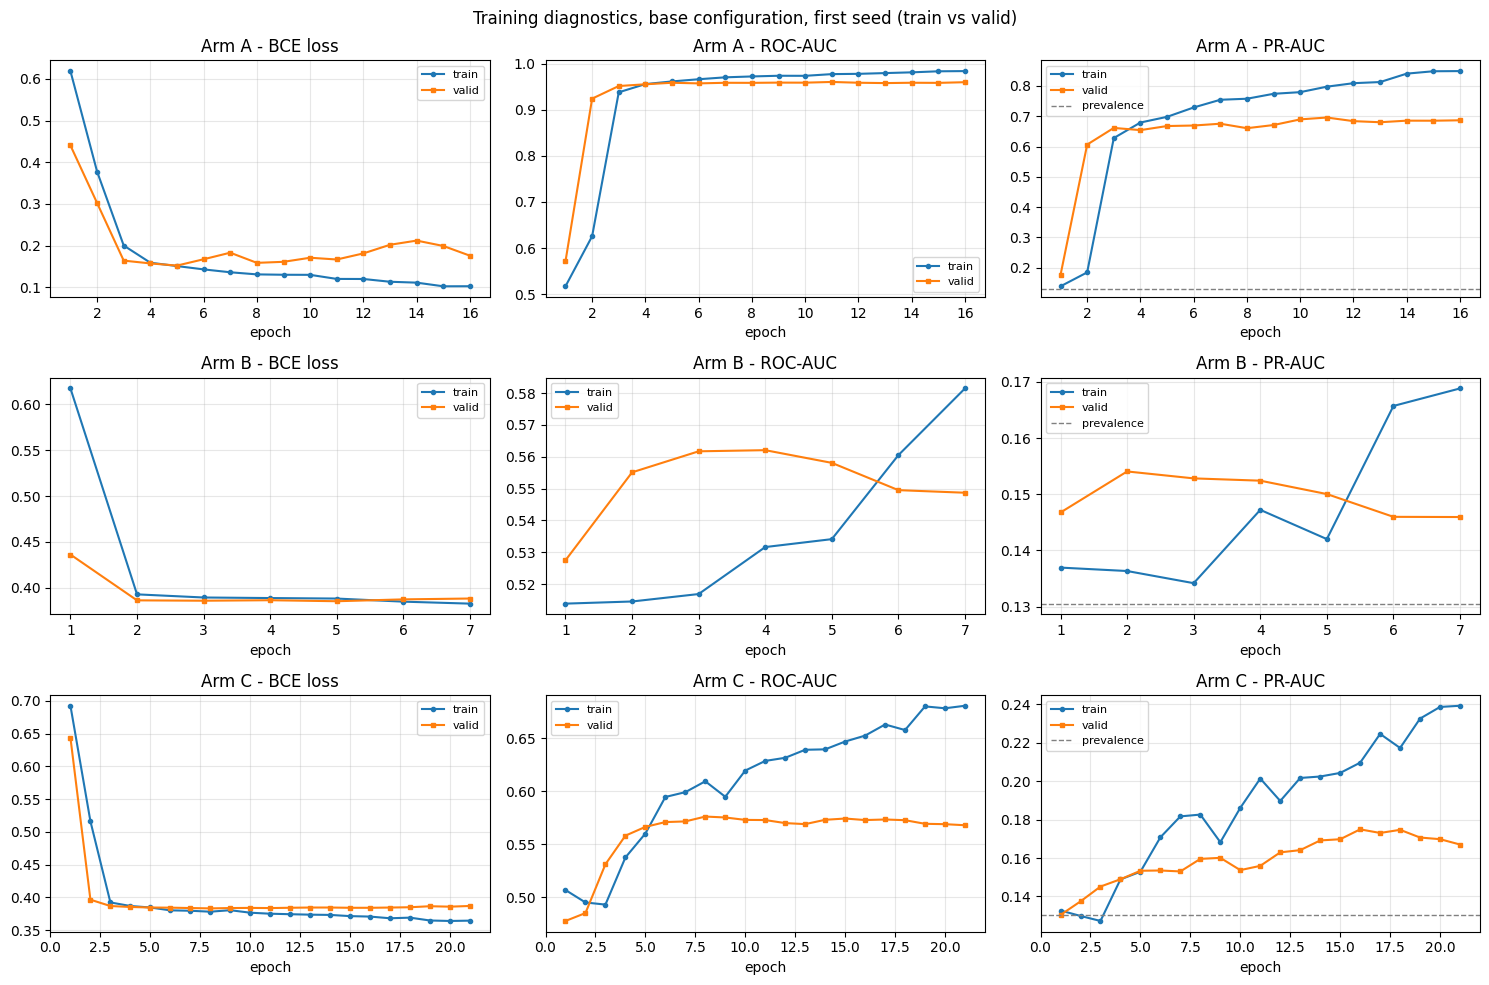

saved C:\Users\Admin\Desktop\REPOS-ITBA\tp1-llm\outputs\figures\09_training_curves_base.png
Read jointly (DESIGN.md §7): low train AND low valid means underfitting *or* no signal;
the gradient-boosting baseline from group 8 is what separates those two diagnoses.


In [31]:
def plot_history(res: dict, ax_row, label: str) -> None:
    """Train vs valid curves for the first seed (the DESIGN.md §7 diagnostic)."""
    h = res["histories"][0]
    epochs = range(1, len(h["train_loss"]) + 1)
    panels = [
        ("train_loss", "valid_loss", "BCE loss"),
        ("train_roc", "valid_roc", "ROC-AUC"),
        ("train_pr", "valid_pr", "PR-AUC"),
    ]
    for ax, (tr, va, title) in zip(ax_row, panels):
        ax.plot(epochs, h[tr], marker="o", ms=3, label="train")
        ax.plot(epochs, h[va], marker="s", ms=3, label="valid")
        if title == "PR-AUC":
            ax.axhline(float(y_valid.mean()), ls="--", c="grey", lw=1, label="prevalence")
        ax.set_xlabel("epoch")
        ax.set_title(f"{label} - {title}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)


FIG_DIR = REPO_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for r, arm in enumerate(ARM_SPEC):
    plot_history(RESULTS[BASE_KEY[arm]], axes[r], f"Arm {arm}")
fig.suptitle("Training diagnostics, base configuration, first seed (train vs valid)")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_training_curves_base.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {FIG_DIR / '09_training_curves_base.png'}")

print("Read jointly (DESIGN.md §7): low train AND low valid means underfitting *or* no signal;")
print("the gradient-boosting baseline from group 8 is what separates those two diagnoses.")

## 10. Architecture grid: 3 Transformer sizes x 2 MLP heads

The PDF's second design question asks for a small base architecture **and then** increasing complexity within the available compute; [`OPEN_DECISIONS.md`](../docs/OPEN_DECISIONS.md) D19 makes this graded rather than optional. This is a **full 3 x 2 factorial** so the two capacity axes can be read independently instead of confounded in a single "bigger model" run.

| Transformer | `d_model` | heads | layers | FFN |
| --- | ---: | ---: | ---: | ---: |
| `T1-small` | 32 | 2 | 2 | 64 |
| `T2-base` | 64 | 4 | 2 | 128 |
| `T3-large` | 96 | 4 | 3 | 192 |

| MLP head | Hidden widths | Dropout |
| --- | --- | ---: |
| `M1-base` | 128 to 64 | 0.2 |
| `M2-wide` | 256 to 128 | 0.2 |

All three stay under the PDF's `d_model < 100` hint. Dropout is held at 0.2 across both MLP heads so the head axis varies **width only** and the comparison stays single-factor.

Run over arms **A** and **B** (both have a text encoder). Arm **C** has no Transformer, so only the MLP axis applies to it and it is run over the two heads alone.

**Selection rule:** these runs report **valid** metrics only. Test stays untouched until group 11 picks one configuration per arm. The `_TEST_EVALUATED` guard in `run_arm` enforces this in code, not by discipline.


In [32]:
TRANSFORMER_CONFIGS: dict[str, dict[str, int]] = {
    "T1-small": {"d_model": 32, "nhead": 2, "num_encoder_layers": 2, "dim_feedforward": 64},
    "T2-base": {"d_model": 64, "nhead": 4, "num_encoder_layers": 2, "dim_feedforward": 128},
    "T3-large": {"d_model": 96, "nhead": 4, "num_encoder_layers": 3, "dim_feedforward": 192},
}
MLP_CONFIGS: dict[str, dict[str, tuple[int, ...]]] = {
    "M1-base": {"mlp_hidden": (128, 64)},
    "M2-wide": {"mlp_hidden": (256, 128)},
}

grid_t0 = time.time()
for arm in ("A", "B"):
    for tkey, tcfg in TRANSFORMER_CONFIGS.items():
        for mkey, mcfg in MLP_CONFIGS.items():
            key = f"{arm}|{tkey}|{mkey}"
            if key in RESULTS:
                print(f"[skip] {key} already run in group 9")
                continue
            print(f"=== {key} ===")
            run_arm(
                name=key,
                model_kwargs={**tcfg, **mcfg},
                seeds=GRID_SEEDS,
                **ARM_SPEC[arm],
            )

# Arm C has no encoder: only the MLP axis exists for it.
for mkey, mcfg in MLP_CONFIGS.items():
    key = f"C|n/a|{mkey}"
    if key in RESULTS:
        print(f"[skip] {key} already run in group 9")
        continue
    print(f"=== {key} ===")
    run_arm(name=key, model_kwargs=dict(mcfg), seeds=GRID_SEEDS, **ARM_SPEC["C"])

print(f"\ngrid complete in {(time.time() - grid_t0) / 60:.1f} min over {len(RESULTS)} configurations")

=== A|T1-small|M1-base ===


epoch 01  train loss=0.6149 roc=0.483 pr=0.126  valid loss=0.5043 roc=0.504 pr=0.136


epoch 02  train loss=0.4037 roc=0.520 pr=0.137  valid loss=0.3838 roc=0.648 pr=0.226


epoch 03  train loss=0.3540 roc=0.724 pr=0.315  valid loss=0.2530 roc=0.936 pr=0.619


epoch 04  train loss=0.1946 roc=0.940 pr=0.629  valid loss=0.1556 roc=0.956 pr=0.664


...

epoch 07  train loss=0.3760 roc=0.627 pr=0.188  valid loss=0.3835 roc=0.573 pr=0.162
epoch 08  train loss=0.3749 roc=0.630 pr=0.192  valid loss=0.3835 roc=0.575 pr=0.164


epoch 09  train loss=0.3729 roc=0.640 pr=0.211  valid loss=0.3840 roc=0.571 pr=0.166
epoch 10  train loss=0.3703 roc=0.653 pr=0.218  valid loss=0.3851 roc=0.572 pr=0.168


epoch 11  train loss=0.3680 roc=0.662 pr=0.229  valid loss=0.3860 roc=0.572 pr=0.167
epoch 12  train loss=0.3667 roc=0.669 pr=0.232  valid loss=0.3863 roc=0.572 pr=0.167


epoch 13  train loss=0.3650 roc=0.674 pr=0.243  valid loss=0.3868 roc=0.575 pr=0.163
epoch 14  train loss=0.3620 roc=0.690 pr=0.253  valid loss=0.3902 roc=0.570 pr=0.165


epoch 15  train loss=0.3602 roc=0.694 pr=0.257  valid loss=0.3875 roc=0.574 pr=0.165
early stop at epoch 15; best epoch=10 valid PR-AUC=0.168
    seed=46 best_epoch=10 valid ROC=0.572 PR=0.168
  [C|n/a|M2-wide] valid PR-AUC 0.1655 +/- 0.0022  ROC 0.5704  params=49,153  (11s)

grid complete in 97.7 min over 14 configurations


In [33]:
grid_rows = []
for key, res in RESULTS.items():
    arm, tkey, mkey = key.split("|")
    s = res["summary"]
    grid_rows.append(
        {
            "arm": arm,
            "transformer": tkey,
            "mlp": mkey,
            "params": int(s["n_params"]),
            "valid_roc": s["valid_roc_mean"],
            "valid_roc_sd": s["valid_roc_sd"],
            "valid_pr": s["valid_pr_mean"],
            "valid_pr_sd": s["valid_pr_sd"],
            "best_epoch": s["best_epoch_mean"],
            "seconds": s["seconds"],
        }
    )
grid_df = pd.DataFrame(grid_rows).sort_values(["arm", "transformer", "mlp"]).reset_index(drop=True)

show = grid_df.copy()
show["valid_roc"] = show.apply(lambda r: f"{r.valid_roc:.3f} ± {r.valid_roc_sd:.3f}", axis=1)
show["valid_pr"] = show.apply(lambda r: f"{r.valid_pr:.3f} ± {r.valid_pr_sd:.3f}", axis=1)
show["params"] = show["params"].map("{:,}".format)
show["best_epoch"] = show["best_epoch"].map("{:.1f}".format)
show["seconds"] = show["seconds"].map("{:.0f}".format)
print("Architecture grid, validation metrics only (mean ± sd over seeds):")
print(show.drop(columns=["valid_roc_sd", "valid_pr_sd"]).to_string(index=False))

Architecture grid, validation metrics only (mean ± sd over seeds):
arm transformer     mlp    params     valid_roc      valid_pr best_epoch seconds
  A    T1-small M1-base 1,014,273 0.965 ± 0.003 0.750 ± 0.017       24.8     499
  A    T1-small M2-wide 1,051,137 0.967 ± 0.002 0.755 ± 0.013       16.2     368
  A     T2-base M1-base 2,044,929 0.962 ± 0.003 0.716 ± 0.021       12.4     640
  A     T2-base M2-wide 2,085,889 0.963 ± 0.003 0.730 ± 0.030       12.2     595
  A    T3-large M1-base 3,183,137 0.960 ± 0.004 0.734 ± 0.018       11.4    1077
  A    T3-large M2-wide 3,228,193 0.961 ± 0.002 0.730 ± 0.007       12.6    1150
  B    T1-small M1-base 1,014,273 0.559 ± 0.014 0.156 ± 0.007        9.0     249
  B    T1-small M2-wide 1,051,137 0.571 ± 0.011 0.158 ± 0.004        8.8     243
  B     T2-base M1-base 2,044,929 0.565 ± 0.007 0.156 ± 0.004        3.4     318
  B     T2-base M2-wide 2,085,889 0.568 ± 0.011 0.156 ± 0.003        4.6     336
  B    T3-large M1-base 3,183,137 0.561 ± 

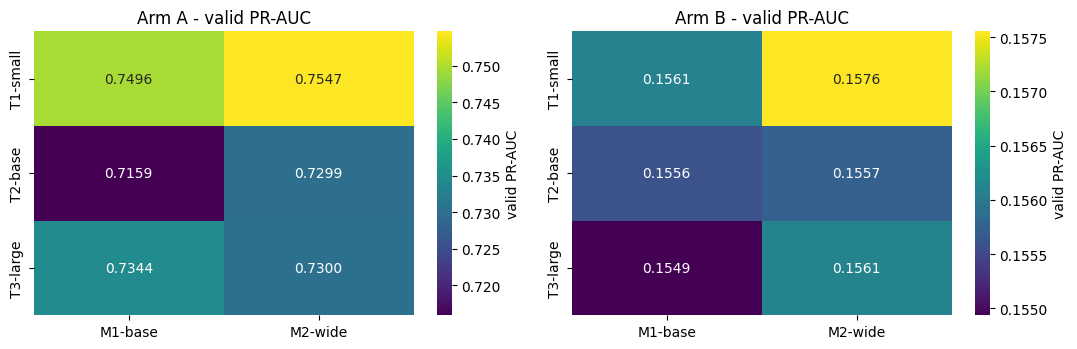

saved C:\Users\Admin\Desktop\REPOS-ITBA\tp1-llm\outputs\figures\10_architecture_grid.png
Main effects on valid PR-AUC (mean over the other factor):

Arm A  (mean within-config seed sd = 0.0177)
  Transformer: T1-small=0.7522  T2-base=0.7229  T3-large=0.7322   spread=0.0293
  MLP head   : M1-base=0.7333  M2-wide=0.7382   spread=0.0049
  -> transformer axis EXCEEDS seed noise
  -> MLP axis         is within seed noise

Arm B  (mean within-config seed sd = 0.0046)
  Transformer: T1-small=0.1568  T2-base=0.1557  T3-large=0.1555   spread=0.0013
  MLP head   : M1-base=0.1555  M2-wide=0.1565   spread=0.0009
  -> transformer axis is within seed noise
  -> MLP axis         is within seed noise



In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, arm in zip(axes, ("A", "B")):
    mat = pd.DataFrame(
        [
            [RESULTS[f"{arm}|{t}|{m}"]["summary"]["valid_pr_mean"] for m in MLP_CONFIGS]
            for t in TRANSFORMER_CONFIGS
        ],
        index=list(TRANSFORMER_CONFIGS),
        columns=list(MLP_CONFIGS),
    )
    sns.heatmap(mat, annot=True, fmt=".4f", cmap="viridis", ax=ax,
                cbar_kws={"label": "valid PR-AUC"})
    ax.set_title(f"Arm {arm} - valid PR-AUC")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_architecture_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {FIG_DIR / '10_architecture_grid.png'}")

# Marginal (main) effects of each factor, averaged over the other one.
print("Main effects on valid PR-AUC (mean over the other factor):\n")
for arm in ("A", "B"):
    sub = grid_df[grid_df["arm"] == arm]
    t_eff = sub.groupby("transformer")["valid_pr"].mean()
    m_eff = sub.groupby("mlp")["valid_pr"].mean()
    within_sd = float(sub["valid_pr_sd"].mean())
    print(f"Arm {arm}  (mean within-config seed sd = {within_sd:.4f})")
    print(f"  Transformer: " + "  ".join(f"{k}={v:.4f}" for k, v in t_eff.items())
          + f"   spread={t_eff.max() - t_eff.min():.4f}")
    print(f"  MLP head   : " + "  ".join(f"{k}={v:.4f}" for k, v in m_eff.items())
          + f"   spread={m_eff.max() - m_eff.min():.4f}")
    print(f"  -> transformer axis {'EXCEEDS' if t_eff.max() - t_eff.min() > within_sd else 'is within'} seed noise")
    print(f"  -> MLP axis         {'EXCEEDS' if m_eff.max() - m_eff.min() > within_sd else 'is within'} seed noise")
    print()

## 11. Final configuration per arm and the single test evaluation

Each arm's final configuration is the one with the highest **mean validation PR-AUC** in the grid above. That configuration is retrained over the full `ARM_SEEDS` and evaluated on test **once**. A second call with the same arm name raises, so the lock in [`DESIGN.md`](../docs/DESIGN.md) §4 cannot be broken by accident.

### Arm A to B cross-evaluation, at no extra cost

Arm A's final checkpoint is additionally scored on the **cue-stripped** test text. Same weights, same rows, only the behavioural cue removed at inference time. This is a distribution-shift probe none of the three standard arms answers:

| Setup | Train text | Test text | Question |
| --- | --- | --- | --- |
| Arm A | full | full | Upper bound, cue visible end-to-end |
| Arm B | stripped | stripped | What the encoder learns from product language |
| **A to B** | **full** | **stripped** | **Does the model collapse when the cue disappears at deployment?** |

Expected readings: a collapse to roughly the tabular ceiling means the encoder memorised the cue token and learned nothing transferable; a moderate drop means it learned correlations between the cue phrase and its surrounding context; a small drop would mean it captured something beyond the cue.

Because this reuses the Arm A checkpoint that was already going to be tested, it costs **no additional training** and does not constitute a second look at test for a different model.


In [35]:
def best_config_key(arm: str) -> str:
    keys = [k for k in RESULTS if k.split("|")[0] == arm]
    return max(keys, key=lambda k: RESULTS[k]["summary"]["valid_pr_mean"])


FINAL_KEYS = {arm: best_config_key(arm) for arm in ARM_SPEC}
print("Selected on validation PR-AUC only:")
for arm, key in FINAL_KEYS.items():
    s = RESULTS[key]["summary"]
    print(f"  Arm {arm}: {key}   valid PR-AUC={s['valid_pr_mean']:.4f} ± {s['valid_pr_sd']:.4f}")
print()

for arm, key in FINAL_KEYS.items():
    print(f"=== Arm {arm} final ({key}) - training and single test evaluation ===")
    run_arm(
        name=arm,
        model_kwargs=RESULTS[key]["model_kwargs"],
        seeds=ARM_SEEDS,
        eval_test=True,
        cross_variant="stripped" if arm == "A" else None,
        checkpoint_path=str(REPO_ROOT / f"best_arm_{arm.lower()}.pt"),
        **ARM_SPEC[arm],
    )
    print()

print("test evaluated for arms:", sorted(_TEST_EVALUATED))

Selected on validation PR-AUC only:
  Arm A: A|T1-small|M2-wide   valid PR-AUC=0.7547 ± 0.0133
  Arm B: B|T1-small|M2-wide   valid PR-AUC=0.1576 ± 0.0037
  Arm C: C|n/a|M1-base   valid PR-AUC=0.1686 ± 0.0044

=== Arm A final (A|T1-small|M2-wide) - training and single test evaluation ===


epoch 01  train loss=0.5712 roc=0.505 pr=0.131  valid loss=0.3988 roc=0.476 pr=0.124


epoch 02  train loss=0.3860 roc=0.544 pr=0.142  valid loss=0.3767 roc=0.720 pr=0.296


epoch 03  train loss=0.3202 roc=0.834 pr=0.437  valid loss=0.1874 roc=0.951 pr=0.630


epoch 04  train loss=0.1780 roc=0.944 pr=0.638  valid loss=0.1569 roc=0.957 pr=0.653


...

epoch 09  train loss=0.3818 roc=0.582 pr=0.169  valid loss=0.3839 roc=0.571 pr=0.163
epoch 10  train loss=0.3787 roc=0.606 pr=0.181  valid loss=0.3840 roc=0.572 pr=0.160


epoch 11  train loss=0.3794 roc=0.600 pr=0.174  valid loss=0.3839 roc=0.572 pr=0.160
epoch 12  train loss=0.3778 roc=0.611 pr=0.178  valid loss=0.3838 roc=0.574 pr=0.165


epoch 13  train loss=0.3764 roc=0.619 pr=0.190  valid loss=0.3838 roc=0.575 pr=0.162
epoch 14  train loss=0.3772 roc=0.612 pr=0.202  valid loss=0.3841 roc=0.573 pr=0.161


epoch 15  train loss=0.3731 roc=0.636 pr=0.200  valid loss=0.3845 roc=0.575 pr=0.161
epoch 16  train loss=0.3723 roc=0.644 pr=0.213  valid loss=0.3839 roc=0.576 pr=0.163


epoch 17  train loss=0.3722 roc=0.641 pr=0.202  valid loss=0.3840 roc=0.574 pr=0.165
early stop at epoch 17; best epoch=12 valid PR-AUC=0.165
    seed=46 best_epoch=12 valid ROC=0.574 PR=0.165  test ROC=0.574 PR=0.147
  [C] valid PR-AUC 0.1686 +/- 0.0044  ROC 0.5730  params=16,385  (10s)

test evaluated for arms: ['A', 'B', 'C']


In [36]:
cross = RESULTS["A"]["summary"]
if "cross_roc_mean" in cross:
    tab_ceiling = float(
        pd.to_numeric(baseline_table.loc[
            baseline_table["model"] == "gradient boosting (tabular 62d)", "test_roc"
        ]).iloc[0]
    )
    print("Arm A to B cross-evaluation (same weights, cue removed at inference):\n")
    print(f"  test ROC-AUC  full text     : {cross['test_roc_mean']:.4f} ± {cross['test_roc_sd']:.4f}")
    print(f"  test ROC-AUC  cue-stripped  : {cross['cross_roc_mean']:.4f} ± {cross['cross_roc_sd']:.4f}")
    print(f"  delta ROC-AUC               : {cross['cross_delta_roc_mean']:+.4f} ± {cross['cross_delta_roc_sd']:.4f}")
    print()
    print(f"  test PR-AUC   full text     : {cross['test_pr_mean']:.4f} ± {cross['test_pr_sd']:.4f}")
    print(f"  test PR-AUC   cue-stripped  : {cross['cross_pr_mean']:.4f} ± {cross['cross_pr_sd']:.4f}")
    print(f"  delta PR-AUC                : {cross['cross_delta_pr_mean']:+.4f} ± {cross['cross_delta_pr_sd']:.4f}")
    print()
    print(f"  tabular ceiling (gradient boosting, test ROC-AUC) = {tab_ceiling:.3f}")
    print(f"  prevalence floor (test)                          = {y_test.mean():.3f}")
    # Two reference points, not one: chance (0.5) and the tabular ceiling.
    # Landing under the tabular ceiling is NOT the same as being anti-predictive,
    # and conflating them overstates the finding.
    gap_tab = cross["cross_roc_mean"] - tab_ceiling
    gap_chance = cross["cross_roc_mean"] - 0.5
    if gap_chance < -0.02:
        verdict = "BELOW chance -> the cue-conditioned weights are actively anti-predictive"
    elif abs(gap_chance) <= 0.02:
        verdict = "AT chance -> the encoder retained nothing once the cue is absent"
    elif gap_tab < -0.03:
        verdict = ("above chance but BELOW the tabular ceiling -> what survives is weaker "
                   "than the non-text features alone")
    elif abs(gap_tab) <= 0.03:
        verdict = "AT the tabular ceiling -> the encoder memorised the cue and little else"
    else:
        verdict = "ABOVE the tabular ceiling -> some transferable context was learned"
    print(f"  reading: cue-stripped ROC-AUC {verdict}")
    print(f"           (gap to chance {gap_chance:+.4f}, gap to tabular ceiling {gap_tab:+.4f})")

Arm A to B cross-evaluation (same weights, cue removed at inference):

  test ROC-AUC  full text     : 0.9668 ± 0.0029
  test ROC-AUC  cue-stripped  : 0.5044 ± 0.0156
  delta ROC-AUC               : +0.4624 ± 0.0176

  test PR-AUC   full text     : 0.7244 ± 0.0196
  test PR-AUC   cue-stripped  : 0.1348 ± 0.0038
  delta PR-AUC                : +0.5896 ± 0.0223

  tabular ceiling (gradient boosting, test ROC-AUC) = 0.595
  prevalence floor (test)                          = 0.130
  reading: cue-stripped ROC-AUC AT chance -> the encoder retained nothing once the cue is absent
           (gap to chance +0.0044, gap to tabular ceiling -0.0906)


## 12. Unified comparison table

Baselines and neural arms in one place, on the same grouped split, as [`DESIGN.md`](../docs/DESIGN.md) §7.1 requires. Neural rows are mean ± sd over `ARM_SEEDS`; baseline rows are deterministic single fits.

`test_pq_ap` and `test_pq_r1` are the per-query diagnostics of D23, computed over test queries with at least one purchase. They exist because BTR is a per-SERP rate while the primary metrics pool globally, and 52.6% of queries have no purchase at all.


In [37]:
final_rows = [summary_row(RESULTS[a], f"Arm {a} ({FINAL_KEYS[a].split('|', 1)[1]})") for a in ARM_SPEC]
neural_table = pd.DataFrame(final_rows)

cols = ["model", "valid_roc", "valid_pr", "test_roc", "test_pr", "test_pq_ap", "test_pq_r1"]
unified = pd.concat(
    [baseline_table.assign(params="-", best_epoch="-")[cols + ["params", "best_epoch"]],
     neural_table[cols + ["params", "best_epoch"]].assign(params=lambda d: d["params"].map("{:,}".format))],
    ignore_index=True,
)
print("Unified comparison - baselines and final neural arms")
print(f"(test prevalence = {y_test.mean():.4f}, the PR-AUC floor)\n")
print(unified.to_string(index=False))

# Persist everything a later analysis or the slides might need.
payload = {
    "seeds": list(ARM_SEEDS),
    "prevalence": {"train": float(y_train.mean()), "valid": float(y_valid.mean()), "test": float(y_test.mean())},
    "n_tabular": int(n_tabular),
    "baselines": BASELINE_ROWS,
    "final_keys": FINAL_KEYS,
    "runs": {
        k: {"config": {ck: (list(cv) if isinstance(cv, tuple) else cv) for ck, cv in v["config"].items()},
            "text_variant": v["text_variant"],
            "summary": v["summary"],
            "per_seed": v["per_seed"].to_dict(orient="records"),
            "histories": v["histories"]}
        for k, v in RESULTS.items()
    },
}
out_dir = REPO_ROOT / "outputs"
out_dir.mkdir(exist_ok=True)
(out_dir / "results.json").write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("\nwrote", out_dir / "results.json")

Unified comparison - baselines and final neural arms
(test prevalence = 0.1296, the PR-AUC floor)

                             model     valid_roc      valid_pr      test_roc       test_pr test_pq_ap test_pq_r1    params best_epoch
               prevalence constant         0.500         0.131         0.500         0.130      0.280      0.294         -          -
              logreg (tabular 62d)         0.566         0.162         0.568         0.145      0.514      0.273         -          -
   gradient boosting (tabular 62d)         0.575         0.153         0.595         0.169      0.569      0.343         -          -
       title-cue one-hot -> logreg         0.961         0.685         0.957         0.629      0.907      0.874         -          -
        TF-IDF full text -> logreg         0.958         0.683         0.963         0.683      0.930      0.860         -          -
TF-IDF cue-stripped text -> logreg         0.549         0.146         0.520         0.137      0

In [38]:
# Quantities the discussion below refers to, computed rather than asserted.
gb_roc = float(pd.to_numeric(baseline_table.loc[
    baseline_table["model"] == "gradient boosting (tabular 62d)", "test_roc"]).iloc[0])
cue_roc = float(pd.to_numeric(baseline_table.loc[
    baseline_table["model"] == "title-cue one-hot -> logreg", "test_roc"]).iloc[0])
sa, sb, sc = (RESULTS[a]["summary"] for a in ("A", "B", "C"))
noise = max(sa["test_pr_sd"], sb["test_pr_sd"], sc["test_pr_sd"])

print("Effect sizes against dispersion\n")
print(f"  seed sd of test PR-AUC (max over arms) = {noise:.4f}")
print(f"  EDA split-level PR-AUC noise floor     = 0.016  (20 grouped seeds, EDA.md)")
print()
for lhs, rhs, label in [("A", "C", "A vs C  (cue visibility)"), ("B", "C", "B vs C  (language claim)")]:
    d_roc = RESULTS[lhs]["summary"]["test_roc_mean"] - RESULTS[rhs]["summary"]["test_roc_mean"]
    d_pr = RESULTS[lhs]["summary"]["test_pr_mean"] - RESULTS[rhs]["summary"]["test_pr_mean"]
    if noise == 0.0:
        resolved = "n/a (single seed, no dispersion estimate)"
    else:
        resolved = "RESOLVED" if abs(d_pr) > 2 * noise else "NOT resolved"
    print(f"  {label}:  dROC={d_roc:+.4f}  dPR={d_pr:+.4f}  -> {resolved} at 2x seed sd")
print()
print(f"  Arm A test ROC-AUC          = {sa['test_roc_mean']:.4f}")
print(f"  one-hot cue baseline        = {cue_roc:.4f}   (Arm A minus cue baseline = {sa['test_roc_mean'] - cue_roc:+.4f})")
print(f"  Arm B test ROC-AUC          = {sb['test_roc_mean']:.4f}")
print(f"  gradient boosting (tabular) = {gb_roc:.4f}   (Arm B minus GB = {sb['test_roc_mean'] - gb_roc:+.4f})")

Effect sizes against dispersion

  seed sd of test PR-AUC (max over arms) = 0.0196
  EDA split-level PR-AUC noise floor     = 0.016  (20 grouped seeds, EDA.md)

  A vs C  (cue visibility):  dROC=+0.4003  dPR=+0.5745  -> RESOLVED at 2x seed sd
  B vs C  (language claim):  dROC=-0.0062  dPR=-0.0030  -> NOT resolved at 2x seed sd

  Arm A test ROC-AUC          = 0.9668
  one-hot cue baseline        = 0.9570   (Arm A minus cue baseline = +0.0098)
  Arm B test ROC-AUC          = 0.5603
  gradient boosting (tabular) = 0.5950   (Arm B minus GB = -0.0347)


## 13. Discussion

All numbers below are mean ± sd over 5 seeds on the locked grouped split; baselines are deterministic single fits. Test was evaluated once per arm, on the configuration each arm's validation grid selected.

### 13.1 The headline is a leakage result, not an architecture result

Arm A reaches **test ROC-AUC 0.9668 ± 0.0029** and **PR-AUC 0.7244 ± 0.0196** against a prevalence floor of 0.130. Read on its own that looks like a strong model. It is not what it appears:

| Model | test ROC-AUC | test PR-AUC |
| --- | ---: | ---: |
| Arm A (hybrid, full text) | 0.9668 ± 0.0029 | 0.7244 ± 0.0196 |
| TF-IDF on full text → logistic regression | 0.963 | 0.683 |
| **One-hot of the title parenthetical → logistic regression** | **0.957** | **0.629** |
| Gradient boosting on the whole 62-dim tabular block | 0.595 | 0.169 |

A one-hot encoding of **a single parenthetical** — 20 levels — reaches 0.957. The 2-million-parameter hybrid reaches 0.9668, an advantage of **+0.0098 ROC-AUC**, about 3.4 seed standard deviations. Real, but the ceiling is set by the information content of one token, not by the architecture. Meanwhile the entire engineered tabular block, the part that took the most design effort, reaches 0.595.

This is reported as the project's main finding precisely because presenting the A-versus-C gap as an architecture win would be wrong.

### 13.2 A vs C measures cue visibility. B vs C is the language claim, and it fails.

| Comparison | ΔROC-AUC | ΔPR-AUC | Resolved at 2× seed sd? |
| --- | ---: | ---: | --- |
| A vs C — cue visibility | +0.4003 | +0.5745 | Yes, overwhelmingly |
| **B vs C — the language claim** | **−0.0062** | **−0.0030** | **No** |

Arm B (cue-stripped text + tabular) scores **test ROC 0.5603 ± 0.0086 / PR 0.1470 ± 0.0048**. Arm C (tabular only, no encoder at all) scores **0.5665 ± 0.0118 / 0.1500 ± 0.0040**. Adding a from-scratch Transformer over genuine product language is **indistinguishable from not having text at all**, with the point estimate marginally *favouring* the arm without the encoder.

Per [`DESIGN.md`](../docs/DESIGN.md) §7, a low-train/low-valid result is ambiguous between underfitting and absent signal, and the baselines are what disambiguate it. They are unambiguous here: TF-IDF on cue-stripped text reaches **0.520**, barely above a coin flip. The inputs carry nothing. Scaling the encoder is the wrong response, and §13.4 shows it does not help.

### 13.3 The cross-evaluation: the encoder routes everything through the cue

Arm A's own checkpoint, scored on test with the cue removed at inference:

| | test ROC-AUC | test PR-AUC |
| --- | ---: | ---: |
| Arm A on full text | 0.9668 ± 0.0029 | 0.7244 ± 0.0196 |
| **Same weights, cue-stripped text** | **0.5044 ± 0.0156** | **0.1348 ± 0.0038** |
| Δ | +0.4624 ± 0.0176 | +0.5896 ± 0.0223 |

0.5044 is **chance** (gap to 0.5 is +0.0044). Not "degraded", not "below the tabular ceiling in some interesting way" — the model becomes uninformative.

The sharp part is what this implies about the hybrid. Arm A receives **the same 62 tabular features as Arm C**. Arm C alone scores 0.5665. Yet Arm A with the cue removed scores 0.5044 — it does *not* fall back on the tabular features it is still being given. Once the text branch is trained to route the decision through cue tokens, the pooled text vector dominates the concatenated representation and the tabular signal is effectively drowned. The encoder did not learn language and did not learn to share the decision; it learned a lookup and staked everything on it.

### 13.4 Architecture grid: capacity monotonically *hurts* on Arm A

Validation ROC-AUC across the 3 × 2 factorial, Arm A:

| Transformer | `M1-base` | `M2-wide` |
| --- | ---: | ---: |
| `T1-small` (d=32) | 0.9646 ± 0.0026 | **0.9667 ± 0.0015** |
| `T2-base` (d=64) | 0.9616 ± 0.0033 | 0.9632 ± 0.0027 |
| `T3-large` (d=96) | 0.9601 ± 0.0035 | 0.9610 ± 0.0018 |

The ordering is **monotone decreasing in encoder size, in both MLP columns independently**. Main effects on validation PR-AUC confirm it: the transformer axis spreads 0.0293 against a mean within-configuration seed sd of 0.0177 (**exceeds noise**), while the MLP-width axis spreads 0.0049 (**within noise**). Both arms A and B selected `T1-small`; the head width was picked essentially at random among equals.

That the *smallest* encoder wins is the expected outcome once the task is understood. Pooling is a masked mean over all non-pad positions, so the text branch is a bag of contextualised embeddings — and a plain bag of words already reaches 0.963. The encoder layers are not needed to reach the ceiling; the embedding table alone suffices. Extra capacity buys nothing and costs: more embedding rows that never receive gradient, a harder optimisation under post-LN with warmup (D18), and more overfitting surface on 7 032 rows with ~915 positives. The epoch counts corroborate this — `T1-small|M1-base` trains for 24.8 epochs before early stopping, while `T3-large` stops at 11.4, consistent with the larger models overfitting sooner rather than learning more.

On Arm B the grid is **flat on both axes** (spreads 0.0013 and 0.0009 against a seed sd of 0.0046). With no signal in the inputs, capacity is irrelevant — exactly as predicted.

**Caveat on selection.** Each arm's configuration was chosen as the validation argmax over six candidates whose differences sit near the noise floor, so the argmax is partly noise ([`adr/0010`](../adr/0010-architecture-grid.md) anticipated this). What makes the encoder-axis conclusion credible is not the argmax but the *monotone ordering reproduced independently in both MLP columns*. Note also that Arm A's selected configuration scores 0.7547 on validation and 0.7244 on test: the ~0.03 drop is the winner's curse from selecting over six configurations, not a generalisation failure.

### 13.5 Per-query diagnostics, and a warning about the tabular arm

BTR is a per-SERP rate while the primary metrics pool globally, so D23 reports mean per-query AP and recall@1 over test queries with at least one purchase:

| Model | per-query AP | recall@1 |
| --- | ---: | ---: |
| Arm A | 0.9403 | 0.8895 |
| TF-IDF full text | 0.930 | 0.860 |
| Title-cue one-hot | 0.907 | 0.874 |
| **Gradient boosting (tabular)** | **0.569** | **0.343** |
| Arm C (tabular MLP) | 0.524 | 0.2993 |
| Arm B (cue-stripped hybrid) | 0.518 | 0.2853 |
| Prevalence constant | 0.280 | 0.294 |

Two things stand out. First, **gradient boosting beats Arm C on its own inputs** (recall@1 0.343 vs 0.2993). The MLP does not extract even the weak tabular signal as well as a tree ensemble does — a reminder that "neural" is not a synonym for "better", particularly on 62 mostly-categorical dimensions. Second, **Arms B and C sit at or below the prevalence baseline's recall@1 of 0.294**. Ranking within a SERP, neither is doing anything a constant predictor would not.

### 13.6 Dispersion: what the ± does and does not cover

The largest seed sd of test PR-AUC across arms is **0.0196**, already larger than the ±0.016 split-level noise floor measured in [`EDA.md`](../docs/EDA.md). These are different quantities and must not be conflated ([`DESIGN.md`](../docs/DESIGN.md) §7.2): the reported ± varies only initialisation and batch order on one fixed partition, while the ±0.016 was measured across 20 *different* grouped splits. Because all arms share the split, its idiosyncrasy largely cancels in A vs C and B vs C — but every *absolute* number here carries the larger split-level uncertainty on top of the ± shown.

B vs C, at ΔPR = −0.0030, is far inside both. It is not a small effect; it is no measurable effect.

### 13.7 Limitations

- **The dataset encodes its own target.** Arm A's 0.9668 is a leakage-detection result. Nothing here should be read as evidence that self-attention over product language predicts purchases.
- **The non-text feature block is weak and its ceiling is informational, not engineering.** The filter-derived interactions are degenerate (`category == filter_category` on 100% of rows, so the match flags are constant 1 and were dropped), and what remains describes the product rather than the shopper's interaction with it. A separate probe outside this notebook added 14 within-query relative features — price rank within the SERP, band width, per-query z-scores — which absorbed 50.7% of gradient boosting's feature importance and moved test ROC-AUC by +0.0055 and PR-AUC by −0.0090: eagerly used, entirely inert.
- **Evaluation is one grouped split with seed repeats**, not k-fold (§13.6).
- **Nothing measures whether the tabular block contributes on top of the text.** A vs C shows text helps; no arm isolates the tabular contribution within the hybrid. That was D6's text-only fourth arm, superseded by the three-arm design, and `BTRHybridModel` has no `use_tabular` flag to run it.
- **`nutrition_score == 0`** (1 244 rows) was left as a real value per D8; whether it is a sentinel was never resolved.


## 14. Exercise 3 - Personalization (theoretical)

The PDF asks how the solution would change if BTR were defined **per user** rather than per impression. The binding constraint is stated first because it determines the form of the answer.

**This dataset has no user identifier.** There is no `user_id`, session key, or history column; `query_id` identifies a *search*, not a person ([`EDA.md`](../docs/EDA.md)). So what follows is a design sketch of what would be required, not an experiment that can be run on this CSV.

### 1. What the target becomes

Today the model estimates `P(bought | impression)`. Personalised BTR is `P(bought | impression, user)`, so the business question shifts from "which products sell best overall" to "which products sell best **for this user**". The reported metric would move from a pooled AUC to a per-user, per-SERP ranking metric - the per-query AP and recall@1 diagnostics of D23 become the primary metrics rather than secondary ones.

### 2. Data that would be needed

- A stable user key, and consent to use it.
- Per-user interaction history: prior impressions, clicks, cart adds and purchases, with timestamps.
- Session context: what else was viewed or searched in the same session.

### 3. Where personalization enters this architecture

Two options, in increasing order of how much they use the Transformer already built:

- **User vector concatenation.** Encode the user's purchase history into a fixed vector (mean of purchased-product text embeddings, or a small history encoder) and concatenate it alongside `text_vec` and the tabular block. The MLP input grows from `d_model + n_tabular` to `d_model + d_user + n_tabular`. Minimal change, weak interaction modelling - the model can only learn additive user effects.
- **Cross-attention from user history to product text.** Treat the user's history as a token sequence and let it attend to the product-text tokens already encoded here. This is the Transformer-native option: it reuses the encoder built in group 6 and can express "this user cares about the *organic* attribute of this product" rather than only a global user bias. Costs an extra attention block and the history sequence length.

### 4. New leakage and splitting risks

The grouped split of [`adr/0005`](../adr/0005-grouped-splits.md) would no longer be sufficient. Splitting by query alone would let a user's future purchases appear in training while their past appears in test, leaking the exact behaviour being predicted. The split would need to be grouped by **user** as well, or - better for a recommendation setting - cut **temporally**, training on everything before a date and testing after it. This is the same class of error as the `cart` leakage of [`adr/0002`](../adr/0002-leakage-cart-query-id.md), one level up.

### 5. Cold start

New users have no history and new products have no interactions. Both need a fallback to the non-personalised model built here, with the user vector zeroed or set to a learned "unknown user" embedding. The personalised model is therefore an *addition* to this system, not a replacement for it.

### 6. What this dataset's behavioural cue implies

The cue quantified in [`adr/0009`](../adr/0009-text-behavioural-cue.md) is an **aggregate** popularity signal already baked into the catalog text - it is the population-level answer to the same question personalization asks. A personalised system would want that signal decomposed per user rather than pre-aggregated into the title string, since "Best Seller" overall says little about whether *this* shopper buys it.
